# Anatomía de una serie de tiempo

Este notebook desarrolla una serie temporal sintética mediante el modelo aditivo:

\[
Y_t=N_t+T_t+S_t+R_t
\]

- \(N_t\): nivel.
- \(T_t\): tendencia.
- \(S_t\): estacionalidad.
- \(R_t\): ruido o residual.

## 1. Importación de librerías
Se cargan las librerías necesarias para manipular datos, generar gráficos, ajustar una tendencia lineal y aplicar descomposición clásica y STL.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Math
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import seasonal_decompose, STL

np.random.seed(42)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

## 2. Construcción de la serie temporal sintética
Se generan 120 observaciones mensuales con nivel constante, tendencia lineal, estacionalidad anual y ruido normal.

In [2]:
n = 120
fechas = pd.date_range(start="2020-01-31", periods=n, freq="ME")
t = np.arange(n)

nivel_real = np.repeat(100.0, n)
tendencia_real = 0.5 * t
estacionalidad_real = 10 * np.sin(2 * np.pi * t / 12)
ruido_real = np.random.normal(loc=0, scale=2, size=n)

valor = nivel_real + tendencia_real + estacionalidad_real + ruido_real

## 3. Creación del DataFrame
Se almacenan la serie observada y sus componentes reales para compararlos posteriormente con las estimaciones.

In [3]:
df = pd.DataFrame({
    "Valor": valor,
    "Nivel_real": nivel_real,
    "Tendencia_real": tendencia_real,
    "Estacionalidad_real": estacionalidad_real,
    "Ruido_real": ruido_real
}, index=fechas)

df.index.name = "Fecha"

## 4. Ecuaciones de generación

\[
N_t=100,\quad T_t=0.5t,\quad S_t=10\sin\left(\frac{2\pi t}{12}\right),\quad R_t\sim\mathcal{N}(0,2^2)
\]

Por tanto:

\[
Y_t=100+0.5t+10\sin\left(\frac{2\pi t}{12}\right)+R_t
\]

In [4]:
print("=" * 80)
print("ECUACIONES DE LA SERIE GENERADA")
print("=" * 80)

display(Math(r"Y_t=N_t+T_t+S_t+R_t"))
display(Math(r"N_t=100"))
display(Math(r"T_t=0.5t"))
display(Math(r"S_t=10\sin\left(\frac{2\pi t}{12}\right)"))
display(Math(r"R_t\sim\mathcal{N}(0,2^2)"))
display(Math(r"Y_t=100+0.5t+10\sin\left(\frac{2\pi t}{12}\right)+R_t"))

ECUACIONES DE LA SERIE GENERADA


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 5. Exploración inicial
Se revisan las primeras y últimas observaciones, la estructura del DataFrame y las estadísticas descriptivas.

In [5]:
print("\n" + "=" * 80)
print("PRIMERAS OBSERVACIONES")
print("=" * 80)
display(df.head())

print("\n" + "=" * 80)
print("ÚLTIMAS OBSERVACIONES")
print("=" * 80)
display(df.tail())

print("\n" + "=" * 80)
print("INFORMACIÓN DEL DATAFRAME")
print("=" * 80)
df.info()

print("\n" + "=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 80)
display(df.describe())

print(f"""
Número de observaciones: {df['Valor'].count()}
Media: {df['Valor'].mean():.2f}
Desviación estándar: {df['Valor'].std():.2f}
Mínimo: {df['Valor'].min():.2f}
Primer cuartil: {df['Valor'].quantile(0.25):.2f}
Mediana: {df['Valor'].median():.2f}
Tercer cuartil: {df['Valor'].quantile(0.75):.2f}
Máximo: {df['Valor'].max():.2f}
""")


PRIMERAS OBSERVACIONES


,Valor,Nivel_real,Tendencia_real,Estacionalidad_real,Ruido_real
Fecha,,,,,
2020-01-31,100.993428,100.0,0.0,0.000000,0.993428
2020-02-29,105.223471,100.0,0.5,5.000000,-0.276529
2020-03-31,110.955631,100.0,1.0,8.660254,1.295377
2020-04-30,114.546060,100.0,1.5,10.000000,3.046060
2020-05-31,110.191947,100.0,2.0,8.660254,-0.468307



ÚLTIMAS OBSERVACIONES


,Valor,Nivel_real,Tendencia_real,Estacionalidad_real,Ruido_real
Fecha,,,,,
2029-08-31,153.103095,100.0,57.5,-5.000000,0.603095
2029-09-30,149.270322,100.0,58.0,-8.660254,-0.069424
2029-10-31,146.162644,100.0,58.5,-10.000000,-2.337356
2029-11-30,152.625392,100.0,59.0,-8.660254,2.285646
2029-12-31,156.003866,100.0,59.5,-5.000000,1.503866



INFORMACIÓN DEL DATAFRAME
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120 entries, 2020-01-31 to 2029-12-31
Freq: ME
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Valor                120 non-null    float64
 1   Nivel_real           120 non-null    float64
 2   Tendencia_real       120 non-null    float64
 3   Estacionalidad_real  120 non-null    float64
 4   Ruido_real           120 non-null    float64
dtypes: float64(5)
memory usage: 5.6 KB

ESTADÍSTICAS DESCRIPTIVAS


,Valor,Nivel_real,Tendencia_real,Estacionalidad_real,Ruido_real
count,120.000000,120.0,120.000000,1.200000e+02,120.000000
mean,129.591662,100.0,29.750000,-3.316032e-16,-0.158338
std,18.432775,0.0,17.392527,7.100716e+00,1.850633
min,94.400797,100.0,0.000000,-1.000000e+01,-5.239490
25%,114.185541,100.0,14.875000,-5.915064e+00,-1.143751
50%,130.322126,100.0,29.750000,-3.673940e-15,-0.146456
75%,144.695827,100.0,44.625000,5.915064e+00,0.765572
max,166.426484,100.0,59.500000,1.000000e+01,4.926484



Número de observaciones: 120
Media: 129.59
Desviación estándar: 18.43
Mínimo: 94.40
Primer cuartil: 114.19
Mediana: 130.32
Tercer cuartil: 144.70
Máximo: 166.43



## 6. Visualización de la serie observada
La gráfica permite identificar la tendencia, la repetición estacional y la variación aleatoria.

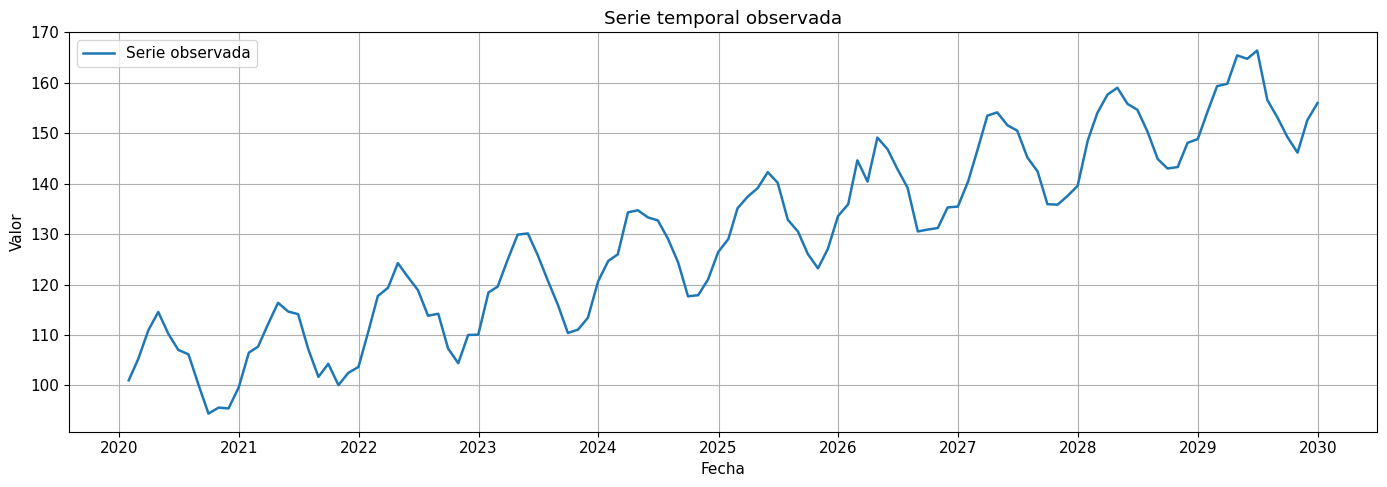


- La serie presenta una tendencia creciente.
- Existe un patrón estacional que se repite cada doce meses.
- La amplitud estacional es aproximadamente constante.
- Las pequeñas variaciones irregulares corresponden al ruido.



In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Valor"], linewidth=1.8, label="Serie observada")
plt.title("Serie temporal observada")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()

print("""
- La serie presenta una tendencia creciente.
- Existe un patrón estacional que se repite cada doce meses.
- La amplitud estacional es aproximadamente constante.
- Las pequeñas variaciones irregulares corresponden al ruido.
""")

DETECCIÓN AUTOMÁTICA DE LA TENDENCIA


,Indicador,Resultado
0,Dirección,creciente
1,Intensidad,fuerte
2,Pendiente por período,0.506019
3,Pendiente relativa,0.003903
4,R²,0.998768
5,Cambio total,58.252937
6,Cambio porcentual,57.240199
7,Intercepto,99.554663



Dirección detectada: creciente

Intensidad de la tendencia: fuerte

Pendiente estimada por período: 0.506019

Pendiente relativa: 0.003903

Coeficiente de determinación R²: 0.998768

Cambio total del componente de tendencia: 58.2529

Cambio porcentual aproximado: 57.2402 %

Ecuación lineal estimada:

T_t = 99.5547 + (0.506019)t

Conclusión: la serie presenta una tendencia general creciente.
La trayectoria de la tendencia es aproximadamente lineal y está bien explicada por la recta estimada.


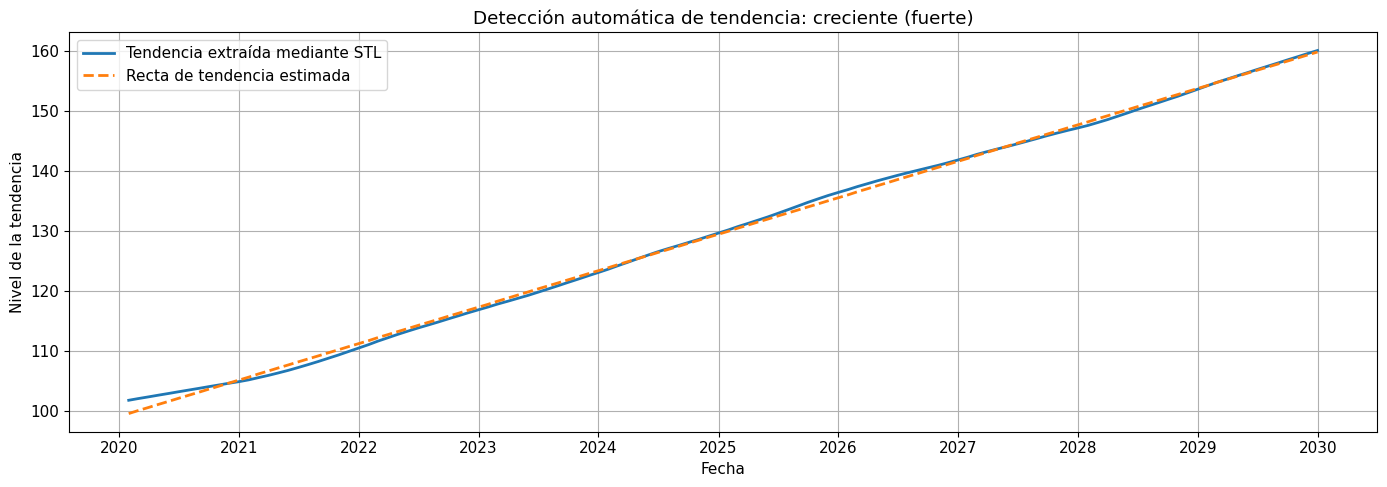

In [22]:
# ============================================================
# DETECCIÓN AUTOMÁTICA DE TENDENCIA EN UNA ÚNICA CELDA
# Requiere que exista previamente:
#
# df["Valor"]
#
# La función:
# 1. limpia la serie;
# 2. extrae la tendencia mediante STL;
# 3. ajusta una regresión lineal;
# 4. clasifica la dirección;
# 5. clasifica la intensidad;
# 6. muestra resultados;
# 7. genera una gráfica.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import STL
from IPython.display import display


def detectar_tendencia(
    serie,
    periodo=12,
    tolerancia_relativa=0.001,
    umbral_r2_fuerte=0.70
):
    """
    Detecta automáticamente la dirección y la intensidad
    de la tendencia de una serie temporal.

    Parámetros
    ----------
    serie:
        Serie temporal de pandas.

    periodo:
        Período estacional.
        Ejemplo: 12 para datos mensuales con ciclo anual.

    tolerancia_relativa:
        Pendiente relativa mínima para considerar que existe
        una tendencia creciente o decreciente.

    umbral_r2_fuerte:
        R² mínimo para considerar que la tendencia lineal
        es fuerte.
    """

    # --------------------------------------------------------
    # 1. Limpieza y validación
    # --------------------------------------------------------

    serie_limpia = serie.dropna().astype(float)

    if len(serie_limpia) < 2 * periodo:
        raise ValueError(
            f"La serie debe contener al menos "
            f"{2 * periodo} observaciones para analizar "
            f"dos ciclos estacionales completos."
        )


    # --------------------------------------------------------
    # 2. Extraer la tendencia mediante STL
    # --------------------------------------------------------

    modelo_stl = STL(
        serie_limpia,
        period=periodo,
        robust=True
    )

    resultado_stl = modelo_stl.fit()

    tendencia_stl = resultado_stl.trend.dropna()


    # --------------------------------------------------------
    # 3. Ajustar regresión lineal sobre la tendencia
    # --------------------------------------------------------

    tiempo = np.arange(
        len(tendencia_stl)
    ).reshape(-1, 1)

    modelo_lineal = LinearRegression()

    modelo_lineal.fit(
        tiempo,
        tendencia_stl.values
    )

    tendencia_lineal = modelo_lineal.predict(tiempo)

    intercepto = modelo_lineal.intercept_

    pendiente = modelo_lineal.coef_[0]

    r2 = modelo_lineal.score(
        tiempo,
        tendencia_stl.values
    )


    # --------------------------------------------------------
    # 4. Calcular pendiente relativa
    # --------------------------------------------------------
    #
    # La pendiente absoluta depende de la escala.
    #
    # Por eso se divide entre el nivel promedio de la
    # tendencia.
    # --------------------------------------------------------

    nivel_promedio = abs(
        tendencia_stl.mean()
    )

    if nivel_promedio < 1e-12:
        pendiente_relativa = pendiente
    else:
        pendiente_relativa = (
            pendiente / nivel_promedio
        )


    # --------------------------------------------------------
    # 5. Clasificar dirección
    # --------------------------------------------------------

    if pendiente_relativa > tolerancia_relativa:

        direccion = "creciente"

    elif pendiente_relativa < -tolerancia_relativa:

        direccion = "decreciente"

    else:

        direccion = "estable"


    # --------------------------------------------------------
    # 6. Clasificar intensidad
    # --------------------------------------------------------

    if direccion == "estable":

        intensidad = "sin tendencia relevante"

    elif r2 >= umbral_r2_fuerte:

        intensidad = "fuerte"

    elif r2 >= 0.40:

        intensidad = "moderada"

    else:

        intensidad = "débil o no lineal"


    # --------------------------------------------------------
    # 7. Calcular cambios
    # --------------------------------------------------------

    cambio_total = (
        tendencia_stl.iloc[-1]
        - tendencia_stl.iloc[0]
    )

    if abs(tendencia_stl.iloc[0]) > 1e-12:

        cambio_porcentual = (
            cambio_total
            / abs(tendencia_stl.iloc[0])
            * 100
        )

    else:

        cambio_porcentual = np.nan


    # --------------------------------------------------------
    # 8. Crear tabla de resultados
    # --------------------------------------------------------

    resultados = {
        "Dirección": direccion,
        "Intensidad": intensidad,
        "Pendiente por período": pendiente,
        "Pendiente relativa": pendiente_relativa,
        "R²": r2,
        "Cambio total": cambio_total,
        "Cambio porcentual": cambio_porcentual,
        "Intercepto": intercepto
    }

    tabla_resultados = pd.DataFrame(
        {
            "Indicador": resultados.keys(),
            "Resultado": resultados.values()
        }
    )


    # --------------------------------------------------------
    # 9. Mostrar resultados
    # --------------------------------------------------------

    print("=" * 80)
    print("DETECCIÓN AUTOMÁTICA DE LA TENDENCIA")
    print("=" * 80)

    display(tabla_resultados)

    print(f"""
Dirección detectada: {direccion}

Intensidad de la tendencia: {intensidad}

Pendiente estimada por período: {pendiente:.6f}

Pendiente relativa: {pendiente_relativa:.6f}

Coeficiente de determinación R²: {r2:.6f}

Cambio total del componente de tendencia: {cambio_total:.4f}

Cambio porcentual aproximado: {cambio_porcentual:.4f} %

Ecuación lineal estimada:

T_t = {intercepto:.4f} + ({pendiente:.6f})t
""")


    # --------------------------------------------------------
    # 10. Interpretación automática
    # --------------------------------------------------------

    if direccion == "creciente":

        print(
            "Conclusión: la serie presenta una tendencia "
            "general creciente."
        )

    elif direccion == "decreciente":

        print(
            "Conclusión: la serie presenta una tendencia "
            "general decreciente."
        )

    else:

        print(
            "Conclusión: no se detecta una tendencia "
            "creciente o decreciente relevante."
        )


    if intensidad == "fuerte":

        print(
            "La trayectoria de la tendencia es "
            "aproximadamente lineal y está bien explicada "
            "por la recta estimada."
        )

    elif intensidad == "moderada":

        print(
            "La tendencia general es visible, pero existen "
            "desviaciones respecto de una trayectoria "
            "perfectamente lineal."
        )

    elif intensidad == "débil o no lineal":

        print(
            "Advertencia: el R² bajo puede indicar una "
            "tendencia curva, cambios estructurales, "
            "variaciones locales o ausencia de una "
            "tendencia lineal clara."
        )


    # --------------------------------------------------------
    # 11. Gráfica
    # --------------------------------------------------------

    plt.figure(figsize=(14, 5))

    plt.plot(
        tendencia_stl.index,
        tendencia_stl,
        linewidth=2,
        label="Tendencia extraída mediante STL"
    )

    plt.plot(
        tendencia_stl.index,
        tendencia_lineal,
        linestyle="--",
        linewidth=2,
        label="Recta de tendencia estimada"
    )

    plt.title(
        "Detección automática de tendencia: "
        f"{direccion} ({intensidad})"
    )

    plt.xlabel("Fecha")

    plt.ylabel("Nivel de la tendencia")

    plt.legend()

    plt.tight_layout()

    plt.show()


    # --------------------------------------------------------
    # 12. Retornar resultados
    # --------------------------------------------------------

    return {
        "resultados": resultados,
        "tabla": tabla_resultados,
        "tendencia_stl": tendencia_stl,
        "tendencia_lineal": tendencia_lineal,
        "modelo_lineal": modelo_lineal,
        "resultado_stl": resultado_stl
    }


# ============================================================
# APLICACIÓN SOBRE LA SERIE
# ============================================================

resultado_tendencia = detectar_tendencia(
    serie=df["Valor"],
    periodo=12,
    tolerancia_relativa=0.001,
    umbral_r2_fuerte=0.70
)

## 7. Componentes reales
Como la serie es sintética, se conocen exactamente los componentes utilizados para construirla.

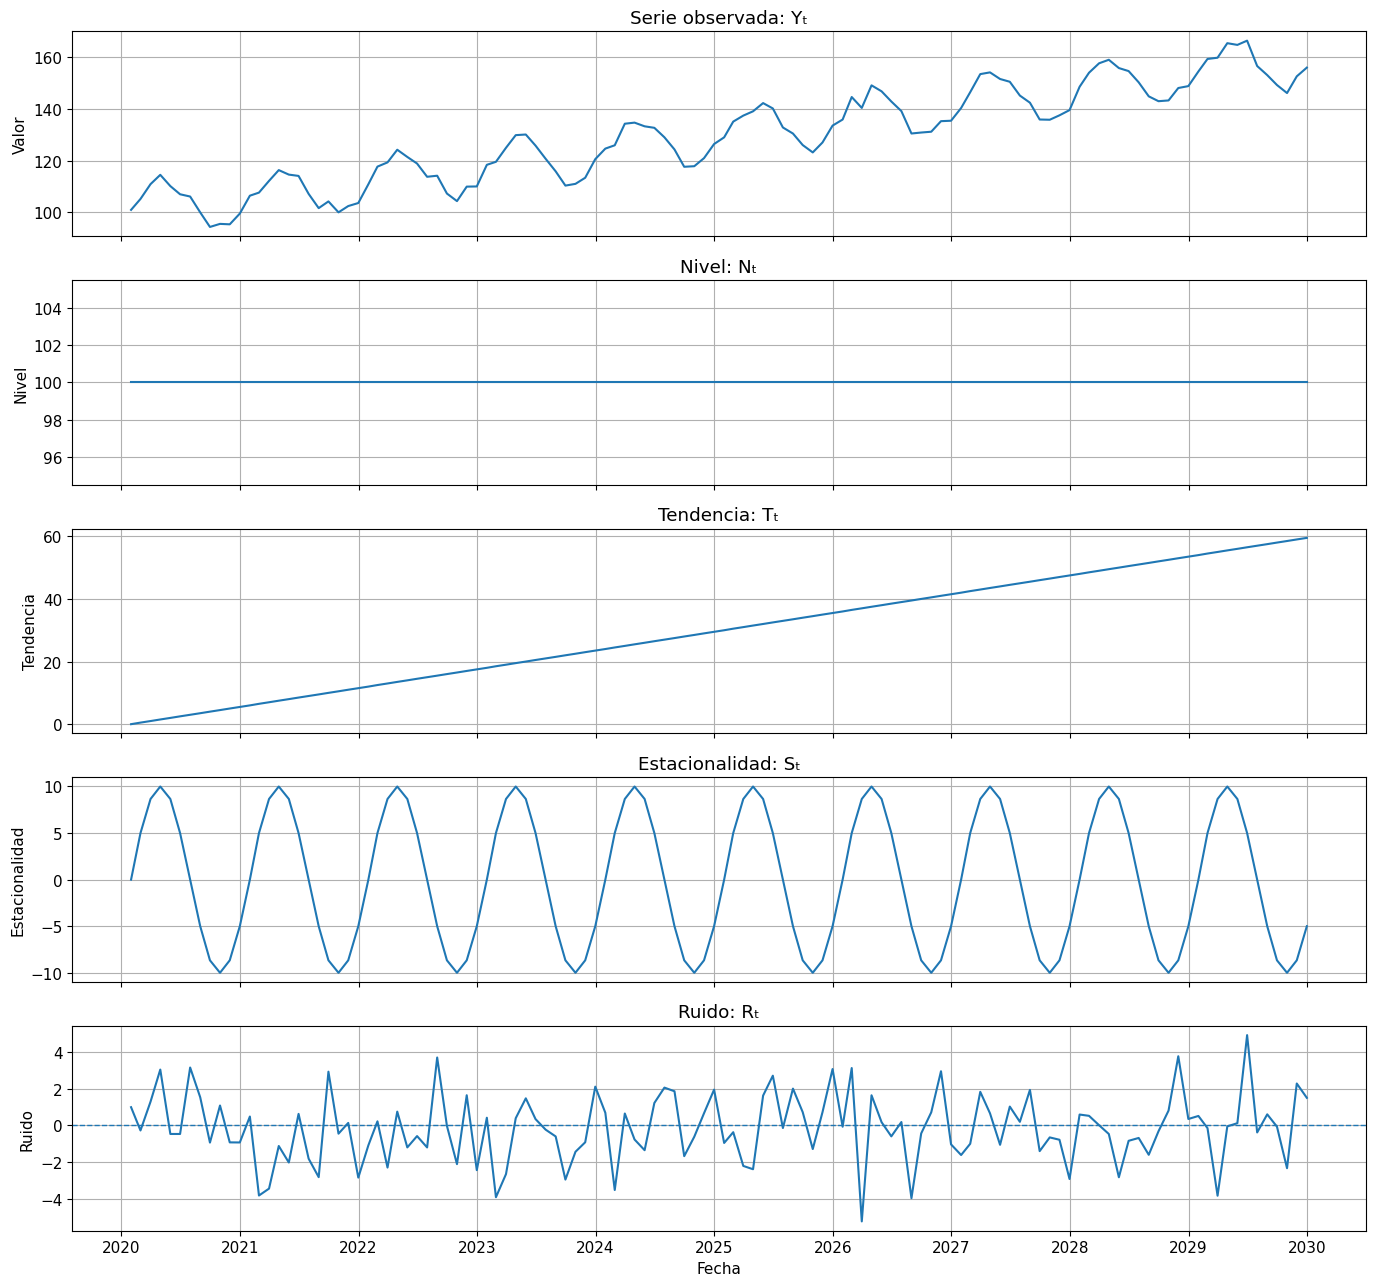

In [7]:
fig, axes = plt.subplots(5, 1, figsize=(14, 13), sharex=True)

axes[0].plot(df.index, df["Valor"])
axes[0].set_title("Serie observada: Yₜ")
axes[0].set_ylabel("Valor")

axes[1].plot(df.index, df["Nivel_real"])
axes[1].set_title("Nivel: Nₜ")
axes[1].set_ylabel("Nivel")

axes[2].plot(df.index, df["Tendencia_real"])
axes[2].set_title("Tendencia: Tₜ")
axes[2].set_ylabel("Tendencia")

axes[3].plot(df.index, df["Estacionalidad_real"])
axes[3].set_title("Estacionalidad: Sₜ")
axes[3].set_ylabel("Estacionalidad")

axes[4].plot(df.index, df["Ruido_real"])
axes[4].axhline(0, linestyle="--", linewidth=1)
axes[4].set_title("Ruido: Rₜ")
axes[4].set_xlabel("Fecha")
axes[4].set_ylabel("Ruido")

plt.tight_layout()
plt.show()

## 8. Descomposición clásica
`seasonal_decompose` separa la serie en observado, tendencia, estacionalidad y residual. Para datos mensuales con estacionalidad anual se utiliza `period=12`.

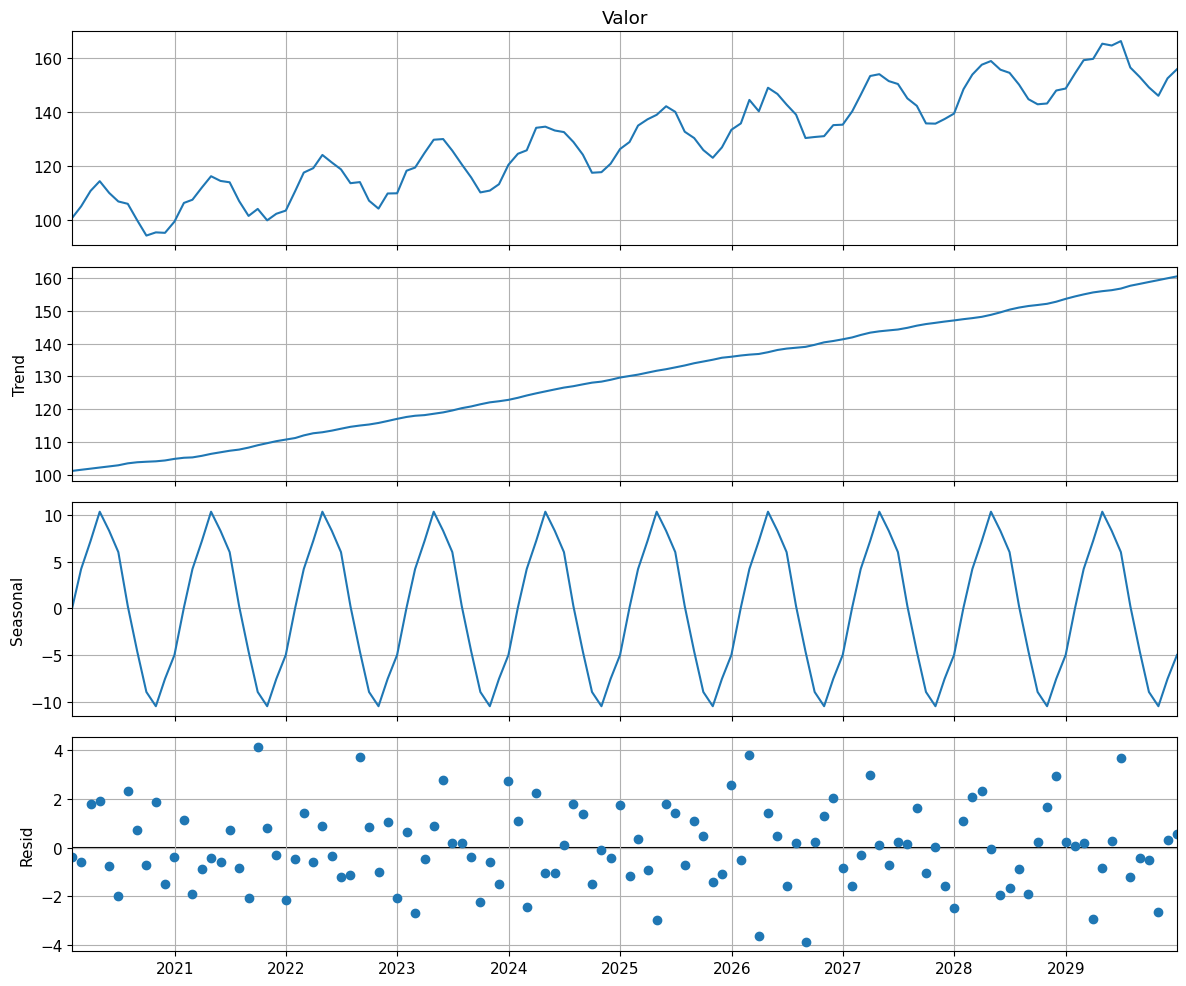


OBSERVED: serie original.
TREND: evolución suavizada de largo plazo; contiene nivel y tendencia.
SEASONAL: patrón que se repite cada doce meses.
RESIDUAL: parte no explicada por tendencia ni estacionalidad.



<IPython.core.display.Math object>

In [8]:
descomposicion = seasonal_decompose(
    df["Valor"],
    model="additive",
    period=12,
    extrapolate_trend="freq"
)

fig = descomposicion.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

print("""
OBSERVED: serie original.
TREND: evolución suavizada de largo plazo; contiene nivel y tendencia.
SEASONAL: patrón que se repite cada doce meses.
RESIDUAL: parte no explicada por tendencia ni estacionalidad.
""")

df["Clasica_Trend"] = descomposicion.trend
df["Clasica_Seasonal"] = descomposicion.seasonal
df["Clasica_Residual"] = descomposicion.resid

display(Math(r"Y_t=\widehat{Trend}_t+\widehat{Seasonal}_t+\widehat{Residual}_t"))

## 9. Estimación del nivel y la tendencia
Se ajusta una regresión lineal:

\[
Y_t=\beta_0+\beta_1t+\varepsilon_t
\]

El intercepto aproxima el nivel inicial y la pendiente representa el crecimiento promedio mensual.

In [9]:
X = t.reshape(-1, 1)
modelo_tendencia = LinearRegression()
modelo_tendencia.fit(X, df["Valor"])

intercepto_estimado = modelo_tendencia.intercept_
pendiente_estimada = modelo_tendencia.coef_[0]

df["Nivel_estimado"] = intercepto_estimado
df["Tendencia_lineal_estimada"] = pendiente_estimada * t
df["Nivel_mas_tendencia"] = df["Nivel_estimado"] + df["Tendencia_lineal_estimada"]

print(f"Nivel inicial estimado: {intercepto_estimado:.4f}")
print(f"Pendiente mensual estimada: {pendiente_estimada:.4f}")
print(f"Crecimiento anual aproximado: {pendiente_estimada * 12:.4f}")

display(Math(rf"\widehat{{N}}_t={intercepto_estimado:.4f}"))
display(Math(rf"\widehat{{T}}_t={pendiente_estimada:.4f}t"))
display(Math(rf"\widehat{{N}}_t+\widehat{{T}}_t={intercepto_estimado:.4f}+{pendiente_estimada:.4f}t"))

Nivel inicial estimado: 100.5214
Pendiente mensual estimada: 0.4886
Crecimiento anual aproximado: 5.8629


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 10. Visualización del nivel y la tendencia estimados
La recta estimada resume la evolución de largo plazo de la serie.

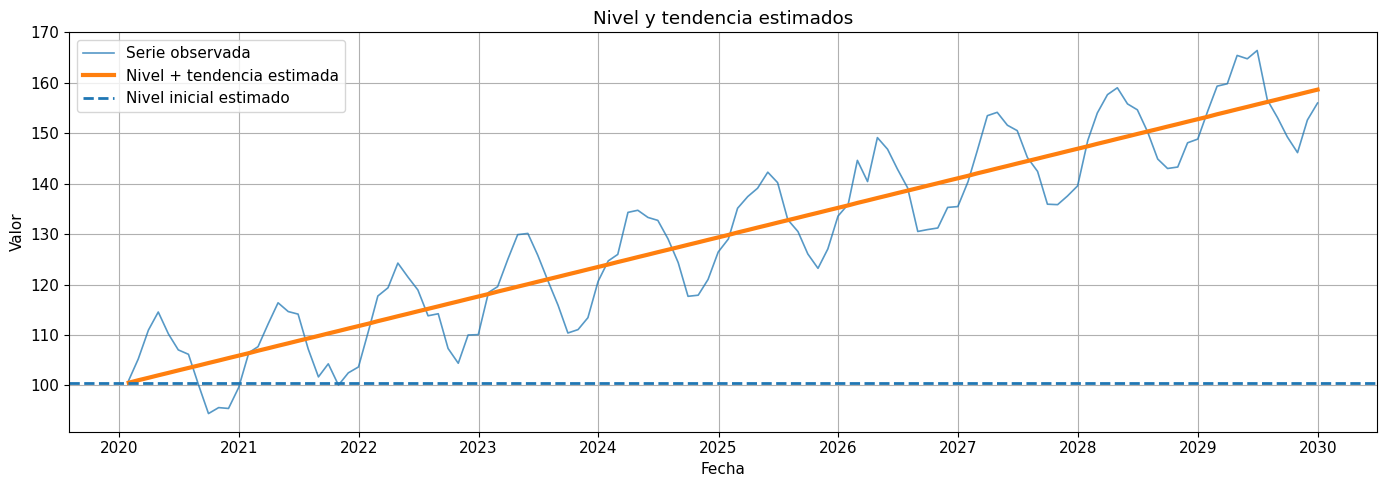

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Valor"], linewidth=1.2, alpha=0.75, label="Serie observada")
plt.plot(df.index, df["Nivel_mas_tendencia"], linewidth=3, label="Nivel + tendencia estimada")
plt.axhline(intercepto_estimado, linestyle="--", linewidth=2, label="Nivel inicial estimado")
plt.title("Nivel y tendencia estimados")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Eliminación del nivel y la tendencia

\[
D_t=Y_t-\widehat{N}_t-\widehat{T}_t
\]

El resultado conserva principalmente la estacionalidad y el ruido.

<IPython.core.display.Math object>

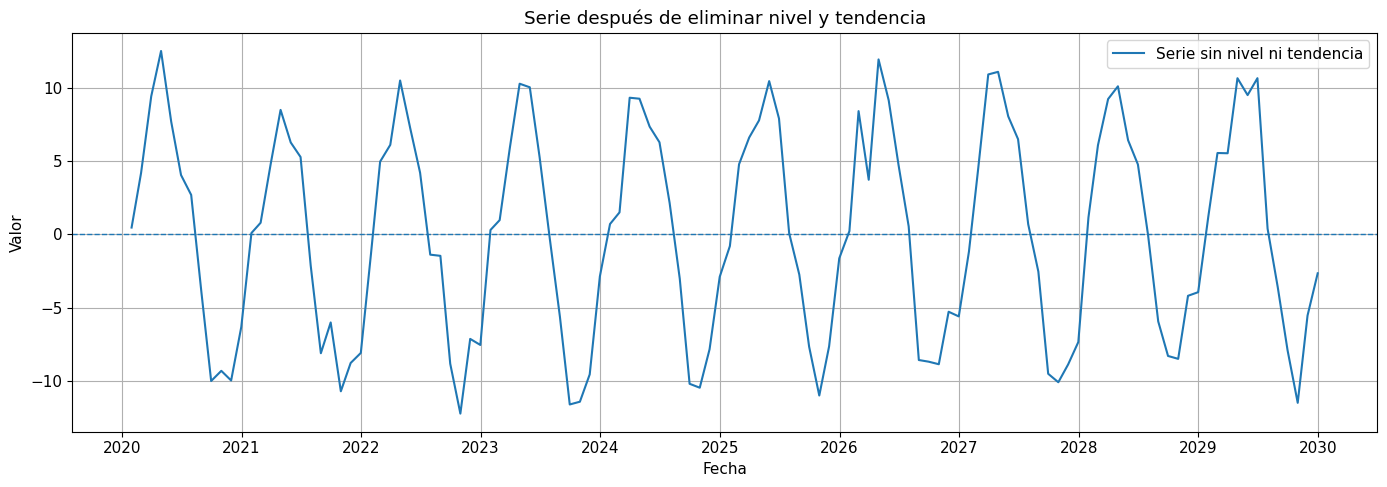

In [11]:
df["Sin_nivel_tendencia"] = df["Valor"] - df["Nivel_mas_tendencia"]

display(Math(r"D_t=Y_t-\widehat{N}_t-\widehat{T}_t"))

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Sin_nivel_tendencia"], label="Serie sin nivel ni tendencia")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Serie después de eliminar nivel y tendencia")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Estimación manual de la estacionalidad
Se promedia la serie sin tendencia para cada mes y se centran los índices para que su suma sea aproximadamente cero.

In [12]:
df["Mes"] = df.index.month

indices_estacionales = df.groupby("Mes")["Sin_nivel_tendencia"].mean()
indices_estacionales = indices_estacionales - indices_estacionales.mean()

nombres_meses = [
    "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

tabla_estacionalidad = pd.DataFrame({
    "Mes": nombres_meses,
    "Indice_estacional": indices_estacionales.values
}, index=np.arange(1, 13))

display(tabla_estacionalidad.round(4))
print(f"Suma de los índices estacionales: {indices_estacionales.sum():.8f}")

df["Estacionalidad_estimada"] = df["Mes"].map(indices_estacionales)

for _, fila in tabla_estacionalidad.iterrows():
    print(f"S_{fila['Mes']} = {fila['Indice_estacional']:.4f}")

,Mes,Indice_estacional
1,Enero,0.0909
2,Febrero,4.1870
3,Marzo,7.1873
4,Abril,10.2981
5,Mayo,8.2472
6,Junio,5.9895
7,Julio,0.2774
8,Agosto,-4.5602
9,Septiembre,-8.8916
10,Octubre,-10.4317


Suma de los índices estacionales: -0.00000000
S_Enero = 0.0909
S_Febrero = 4.1870
S_Marzo = 7.1873
S_Abril = 10.2981
S_Mayo = 8.2472
S_Junio = 5.9895
S_Julio = 0.2774
S_Agosto = -4.5602
S_Septiembre = -8.8916
S_Octubre = -10.4317
S_Noviembre = -7.4958
S_Diciembre = -4.8980


## 13. Gráficas de la estacionalidad estimada
La primera gráfica muestra los índices mensuales y la segunda su repetición a lo largo del tiempo.

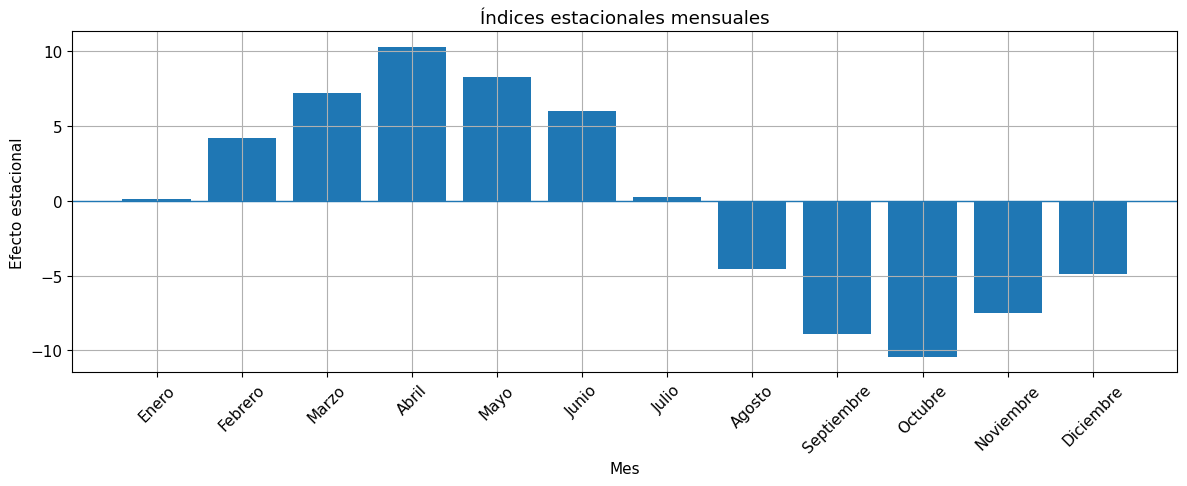

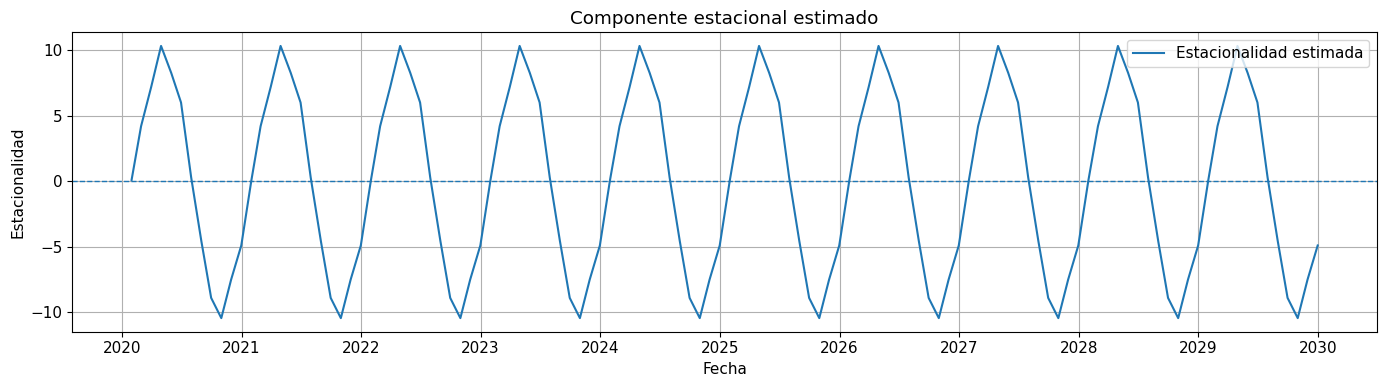

,Índice estacional centrado
Mes,
1,0.0909
2,4.1870
3,7.1873
4,10.2981
5,8.2472
6,5.9895
7,0.2774
8,-4.5602
9,-8.8916



TABLA FINAL DE ÍNDICES ESTACIONALES


,Mes,Índice estacional
Mes,,
1,Enero,0.0909
2,Febrero,4.1870
3,Marzo,7.1873
4,Abril,10.2981
5,Mayo,8.2472
6,Junio,5.9895
7,Julio,0.2774
8,Agosto,-4.5602
9,Septiembre,-8.8916



INTERPRETACIÓN DE CADA ÍNDICE ESTACIONAL
Enero: aumenta la serie aproximadamente 0.09 unidades respecto a la tendencia.
Febrero: aumenta la serie aproximadamente 4.19 unidades respecto a la tendencia.
Marzo: aumenta la serie aproximadamente 7.19 unidades respecto a la tendencia.
Abril: aumenta la serie aproximadamente 10.30 unidades respecto a la tendencia.
Mayo: aumenta la serie aproximadamente 8.25 unidades respecto a la tendencia.
Junio: aumenta la serie aproximadamente 5.99 unidades respecto a la tendencia.
Julio: aumenta la serie aproximadamente 0.28 unidades respecto a la tendencia.
Agosto: reduce la serie aproximadamente 4.56 unidades respecto a la tendencia.
Septiembre: reduce la serie aproximadamente 8.89 unidades respecto a la tendencia.
Octubre: reduce la serie aproximadamente 10.43 unidades respecto a la tendencia.
Noviembre: reduce la serie aproximadamente 7.50 unidades respecto a la tendencia.
Diciembre: reduce la serie aproximadamente 4.90 unidades respecto a la tendenc

In [28]:
plt.figure(figsize=(12, 5))
plt.bar(tabla_estacionalidad["Mes"], tabla_estacionalidad["Indice_estacional"])
plt.axhline(0, linewidth=1)
plt.title("Índices estacionales mensuales")
plt.xlabel("Mes")
plt.ylabel("Efecto estacional")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Estacionalidad_estimada"], label="Estacionalidad estimada")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Componente estacional estimado")
plt.xlabel("Fecha")
plt.ylabel("Estacionalidad")
plt.legend()
plt.tight_layout()
plt.show()




display(
    indices_estacionales
    .to_frame("Índice estacional centrado")
    .round(4)
)


# ------------------------------------------------------------
# 4. Crear tabla con los nombres de los meses
# ------------------------------------------------------------

nombres_meses = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
}

tabla_indices = (
    indices_estacionales
    .to_frame("Índice estacional")
)

tabla_indices["Mes"] = (
    tabla_indices.index.map(nombres_meses)
)

tabla_indices = tabla_indices[
    ["Mes", "Índice estacional"]
]


print("\n" + "=" * 80)
print("TABLA FINAL DE ÍNDICES ESTACIONALES")
print("=" * 80)

display(
    tabla_indices.round(4)
)


# ------------------------------------------------------------
# 7. Interpretación automática de cada mes
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("INTERPRETACIÓN DE CADA ÍNDICE ESTACIONAL")
print("=" * 80)

for numero_mes, fila in tabla_indices.iterrows():

    mes = fila["Mes"]
    indice = fila["Índice estacional"]

    if indice > 0:

        interpretacion = (
            f"aumenta la serie aproximadamente "
            f"{indice:.2f} unidades respecto a la tendencia"
        )

    elif indice < 0:

        interpretacion = (
            f"reduce la serie aproximadamente "
            f"{abs(indice):.2f} unidades respecto a la tendencia"
        )

    else:

        interpretacion = (
            "no produce un efecto estacional apreciable"
        )

    print(
        f"{mes}: {interpretacion}."
    )


# ------------------------------------------------------------
# 8. Identificar el mayor y el menor efecto estacional
# ------------------------------------------------------------

mes_mayor = tabla_indices.loc[
    tabla_indices["Índice estacional"].idxmax()
]

mes_menor = tabla_indices.loc[
    tabla_indices["Índice estacional"].idxmin()
]


print("\n" + "=" * 80)
print("RESUMEN ESTACIONAL")
print("=" * 80)

print(
    f"Mayor efecto estacional: "
    f"{mes_mayor['Mes']} "
    f"({mes_mayor['Índice estacional']:.2f})"
)

print(
    f"Menor efecto estacional: "
    f"{mes_menor['Mes']} "
    f"({mes_menor['Índice estacional']:.2f})"
)

# ------------------------------------------------------------
# 11. Conclusión automática
# ------------------------------------------------------------

print("=" * 80)
print("CONCLUSIÓN")
print("=" * 80)

print("""
Cada índice estacional indica cuánto se espera que un mes
aumente o disminuya el valor de la serie respecto a su nivel
y tendencia.

Los índices positivos representan meses que elevan la serie.

Los índices negativos representan meses que reducen la serie.

Como se utiliza un modelo aditivo, los efectos de los doce
meses se compensan a lo largo de un ciclo completo.

Por eso la suma y el promedio de los índices centrados son
aproximadamente cero.
""")


## 14. Estimación del ruido

\[
\widehat{R}_t=Y_t-\widehat{N}_t-\widehat{T}_t-\widehat{S}_t
\]

El residual ideal debe oscilar alrededor de cero y no conservar patrones sistemáticos.

,Ruido_estimado
count,1.200000e+02
mean,-6.898186e-15
std,1.787883e+00
min,-4.033782e+00
25%,-1.269895e+00
50%,2.309311e-02
75%,1.230460e+00
max,4.706518e+00


Media del ruido: -0.000000
Desviación estándar del ruido: 1.787883


<IPython.core.display.Math object>

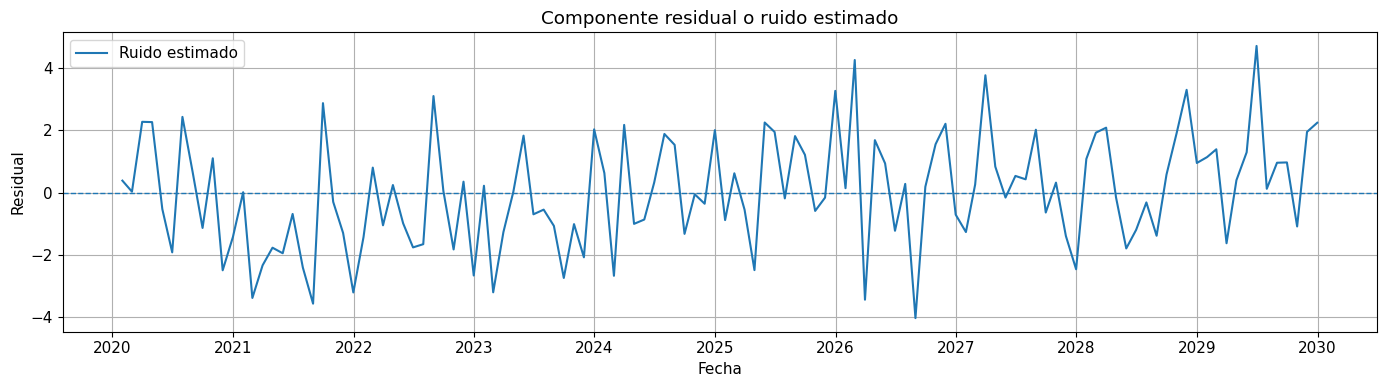

In [14]:
df["Ruido_estimado"] = (
    df["Valor"]
    - df["Nivel_estimado"]
    - df["Tendencia_lineal_estimada"]
    - df["Estacionalidad_estimada"]
)

media_ruido = df["Ruido_estimado"].mean()
desviacion_ruido = df["Ruido_estimado"].std()

display(df["Ruido_estimado"].describe().to_frame("Ruido_estimado"))
print(f"Media del ruido: {media_ruido:.6f}")
print(f"Desviación estándar del ruido: {desviacion_ruido:.6f}")

display(Math(r"\widehat{R}_t=Y_t-\widehat{N}_t-\widehat{T}_t-\widehat{S}_t"))

plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Ruido_estimado"], label="Ruido estimado")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Componente residual o ruido estimado")
plt.xlabel("Fecha")
plt.ylabel("Residual")
plt.legend()
plt.tight_layout()
plt.show()

## 15. Modelo aditivo completo estimado

\[
\widehat{Y}_t=\widehat{N}_t+\widehat{T}_t+\widehat{S}_t+\widehat{R}_t
\]

In [15]:
display(Math(r"\widehat{Y}_t=\widehat{N}_t+\widehat{T}_t+\widehat{S}_t+\widehat{R}_t"))
display(Math(rf"\widehat{{Y}}_t={intercepto_estimado:.4f}+{pendiente_estimada:.4f}t+\widehat{{S}}_t+\widehat{{R}}_t"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Residuales en modelos aditivos y multiplicativos

### Modelo aditivo

En un modelo aditivo, la serie se representa como:

\[
Y_t = T_t + S_t + R_t
\]

donde:

- \(Y_t\): valor observado de la serie;
- \(T_t\): tendencia;
- \(S_t\): componente estacional;
- \(R_t\): componente residual.

El residual se calcula como:

\[
R_t = Y_t - T_t - S_t
\]

En este caso, el residual ideal debe fluctuar alrededor de:

\[
0
\]

Esto significa que, después de eliminar la tendencia y la estacionalidad, no debería quedar un patrón sistemático.

---

### Modelo multiplicativo

En un modelo multiplicativo, la serie se representa como:

\[
Y_t = T_t \cdot S_t \cdot R_t
\]

El residual se calcula como:

\[
R_t = \frac{Y_t}{T_t \cdot S_t}
\]

En este caso, el residual ideal debe fluctuar alrededor de:

\[
1
\]

Esto ocurre porque un residual igual a 1 no modifica el producto entre la tendencia y la estacionalidad.

---

### Interpretación

- En el modelo aditivo, un residual cercano a \(0\) indica que la tendencia y la estacionalidad explican adecuadamente la serie.
- En el modelo multiplicativo, un residual cercano a \(1\) indica que la tendencia y la estacionalidad explican adecuadamente la serie.
- En ambos casos, los residuos no deberían mostrar tendencia, estacionalidad ni patrones repetitivos.

## Selección automática entre descomposición aditiva y multiplicativa

Este bloque de código compara dos formas posibles de representar una serie temporal con estacionalidad:

### Modelo aditivo

\[
Y_t = T_t + S_t + R_t
\]

En este modelo, la amplitud de las fluctuaciones estacionales se mantiene aproximadamente constante aunque cambie el nivel de la serie.

Por ejemplo, si la serie aumenta de 100 a 200, pero continúa oscilando aproximadamente \(\pm 10\) unidades, la estructura es compatible con un modelo aditivo.

### Modelo multiplicativo

\[
Y_t = T_t \cdot S_t \cdot R_t
\]

En este modelo, la amplitud estacional cambia de manera proporcional al nivel de la serie.

Por ejemplo, si con un nivel de 100 la serie oscila \(\pm 10\), pero con un nivel de 200 oscila \(\pm 20\), la estructura es compatible con un modelo multiplicativo.

---

## ¿Qué hace el código?

La función `seleccionar_tipo_descomposicion()` recibe una serie temporal y compara automáticamente ambos modelos mediante varios criterios.

### 1. Valida la serie

El código verifica que:

- existan suficientes observaciones;
- el período estacional sea válido;
- la serie no contenga valores cero o negativos cuando se evalúa el modelo multiplicativo.

La descomposición multiplicativa requiere valores estrictamente positivos porque utiliza divisiones y productos entre sus componentes.

### 2. Calcula las dos descomposiciones

Se ajustan dos modelos utilizando `seasonal_decompose`:

- una descomposición aditiva;
- una descomposición multiplicativa.

En ambos casos se obtienen:

- tendencia;
- estacionalidad;
- residual.

### 3. Compara los residuos en una escala similar

Los residuos de ambos modelos no pueden compararse directamente porque tienen interpretaciones diferentes.

En el modelo aditivo, el residual ideal está alrededor de cero:

\[
R_t \approx 0
\]

En el modelo multiplicativo, el residual ideal está alrededor de uno:

\[
R_t \approx 1
\]

Para hacerlos comparables:

- el residual aditivo se divide por la tendencia;
- al residual multiplicativo se le aplica logaritmo.

De esta manera, ambos residuos quedan expresados aproximadamente como desviaciones relativas alrededor de cero.

### 4. Calcula MAE y RMSE de los residuos

El código calcula:

- MAE residual normalizado;
- RMSE residual normalizado.

Un valor menor indica que el modelo deja residuos de menor magnitud y, por tanto, explica mejor la estructura de la serie.

### 5. Aplica la prueba de Ljung–Box

La prueba de Ljung–Box permite determinar si todavía existe autocorrelación en los residuos.

La hipótesis nula es:

\[
H_0:
\text{los residuos no presentan autocorrelación conjunta}
\]

La interpretación es:

- \(p>0.05\): no se rechaza la ausencia de autocorrelación;
- \(p\leq 0.05\): todavía quedan patrones temporales sin explicar.

El modelo más adecuado debería dejar residuos cercanos a ruido blanco.

### 6. Analiza la relación entre nivel y amplitud

La serie se divide en ciclos completos. Para cada ciclo se calcula:

- nivel promedio;
- valor mínimo;
- valor máximo;
- amplitud;
- amplitud relativa.

La amplitud se calcula como:

\[
A_c=\max(Y_c)-\min(Y_c)
\]

Después se analiza la correlación entre el nivel promedio y la amplitud.

- Una correlación baja favorece el modelo aditivo.
- Una correlación alta favorece el modelo multiplicativo.

Esto se debe a que, en una estructura multiplicativa, la amplitud aumenta cuando aumenta el nivel de la serie.

### 7. Asigna una puntuación a cada modelo

El código entrega puntos de acuerdo con tres criterios:

1. menor RMSE residual normalizado;
2. mayor valor \(p\) en Ljung–Box;
3. relación entre nivel y amplitud.

El modelo que obtiene más evidencia es seleccionado como:

- `ADITIVO`;
- `MULTIPLICATIVO`;
- `NO CONCLUYENTE`.

### 8. Genera una conclusión automática

La salida muestra:

- modelo sugerido;
- nivel de evidencia;
- puntuación de cada modelo;
- razones que favorecen la decisión.

Un resultado `NO CONCLUYENTE` significa que los criterios no coinciden suficientemente. En ese caso deben revisarse:

- las gráficas;
- posibles valores atípicos;
- cambios estructurales;
- cantidad de ciclos disponibles;
- una posible transformación logarítmica.

---

## Gráficas generadas

El código produce varias visualizaciones:

1. Serie temporal original.
2. Relación entre nivel y amplitud estacional.
3. Comparación de residuos normalizados.
4. Descomposición aditiva.
5. Descomposición multiplicativa.

Estas gráficas permiten verificar visualmente la conclusión obtenida automáticamente.

---

## Interpretación de la salida

Si el código concluye:

```text
Modelo sugerido: ADITIVO

COMPARACIÓN: MODELO ADITIVO VS. MULTIPLICATIVO


,Modelo,MAE residual normalizado,RMSE residual normalizado,p-valor Ljung-Box lag 24,¿Residual compatible con ruido blanco?,Puntos
0,Aditivo,0.010158,0.012707,0.034675,No,3
1,Multiplicativo,0.011656,0.014442,0.003487,No,0



RELACIÓN ENTRE NIVEL Y AMPLITUD


,Nivel_promedio,Minimo,Maximo,Desviacion,Amplitud,Amplitud_relativa
Ciclo,,,,,,
0,103.3419,94.4008,114.5461,6.6687,20.1453,0.1949
1,107.5675,100.0484,116.3754,5.5338,16.3270,0.1518
2,114.3633,104.3846,124.2514,6.0628,19.8668,0.1737
3,120.0848,110.3827,130.1372,6.7146,19.7545,0.1645
4,126.8458,117.6613,134.7298,6.1025,17.0685,0.1346
5,133.0415,123.2098,142.2853,6.0399,19.0755,0.1434
6,138.5367,130.5249,149.1438,6.3560,18.6189,0.1344
7,144.4330,135.8447,154.1575,6.7906,18.3128,0.1268
8,150.6917,143.0172,159.0308,5.5027,16.0137,0.1063



Correlación entre nivel y amplitud: -0.1072
Coeficiente de variación de la amplitud relativa: 0.1776

CONCLUSIÓN AUTOMÁTICA
Modelo sugerido: ADITIVO
Nivel de evidencia: alta
Puntuación aditiva: 3/3
Puntuación multiplicativa: 0/3

La evidencia favorece una estructura aditiva:

Y_t = T_t + S_t + R_t

La amplitud de las fluctuaciones estacionales se mantiene
relativamente constante frente a los cambios en el nivel.

Razones:
- presenta menor dispersión residual normalizada.
- presenta residuos con menor evidencia de autocorrelación.
- la amplitud estacional es poco dependiente del nivel.


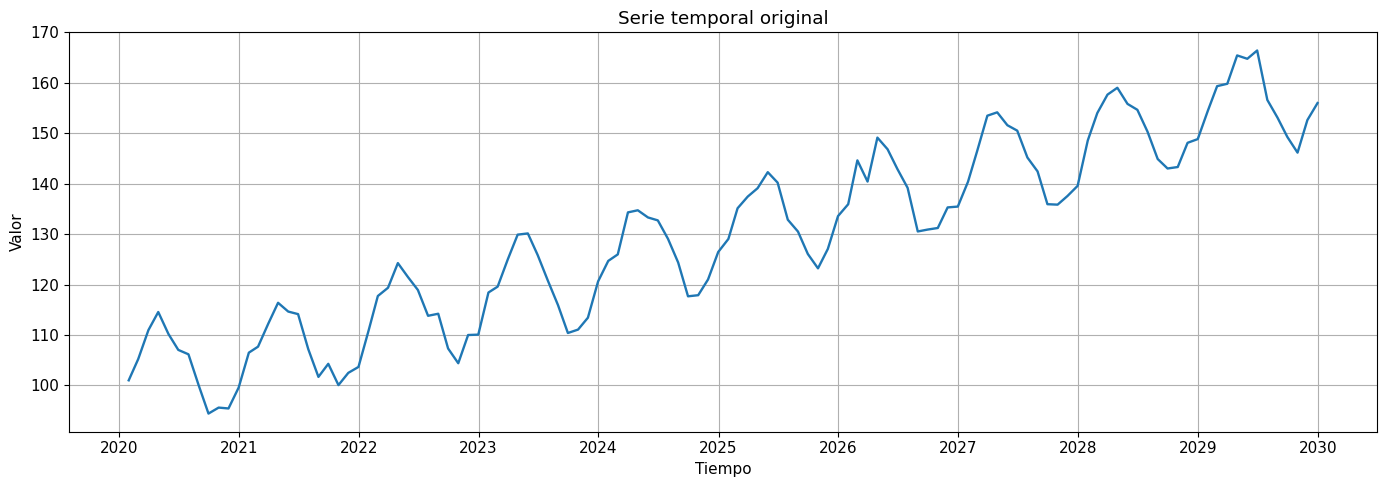

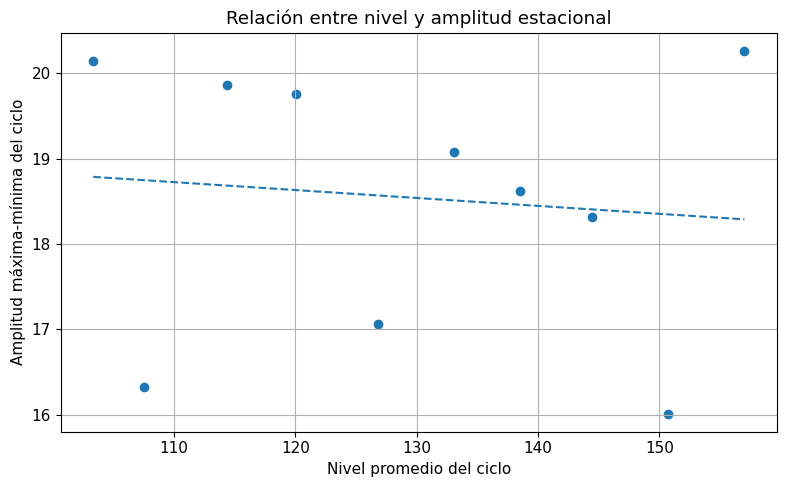

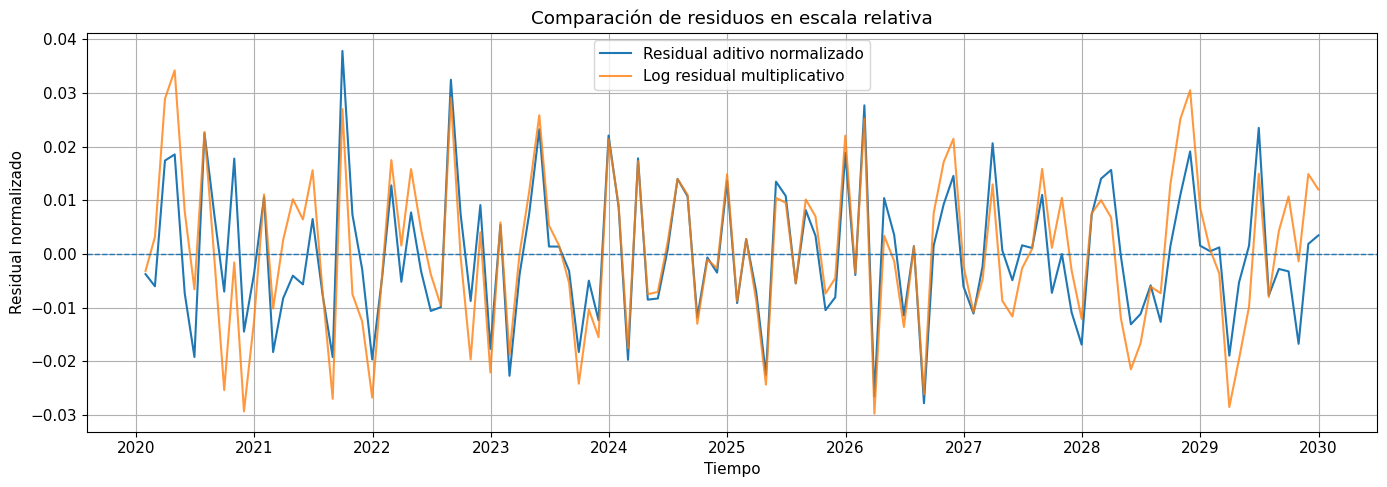

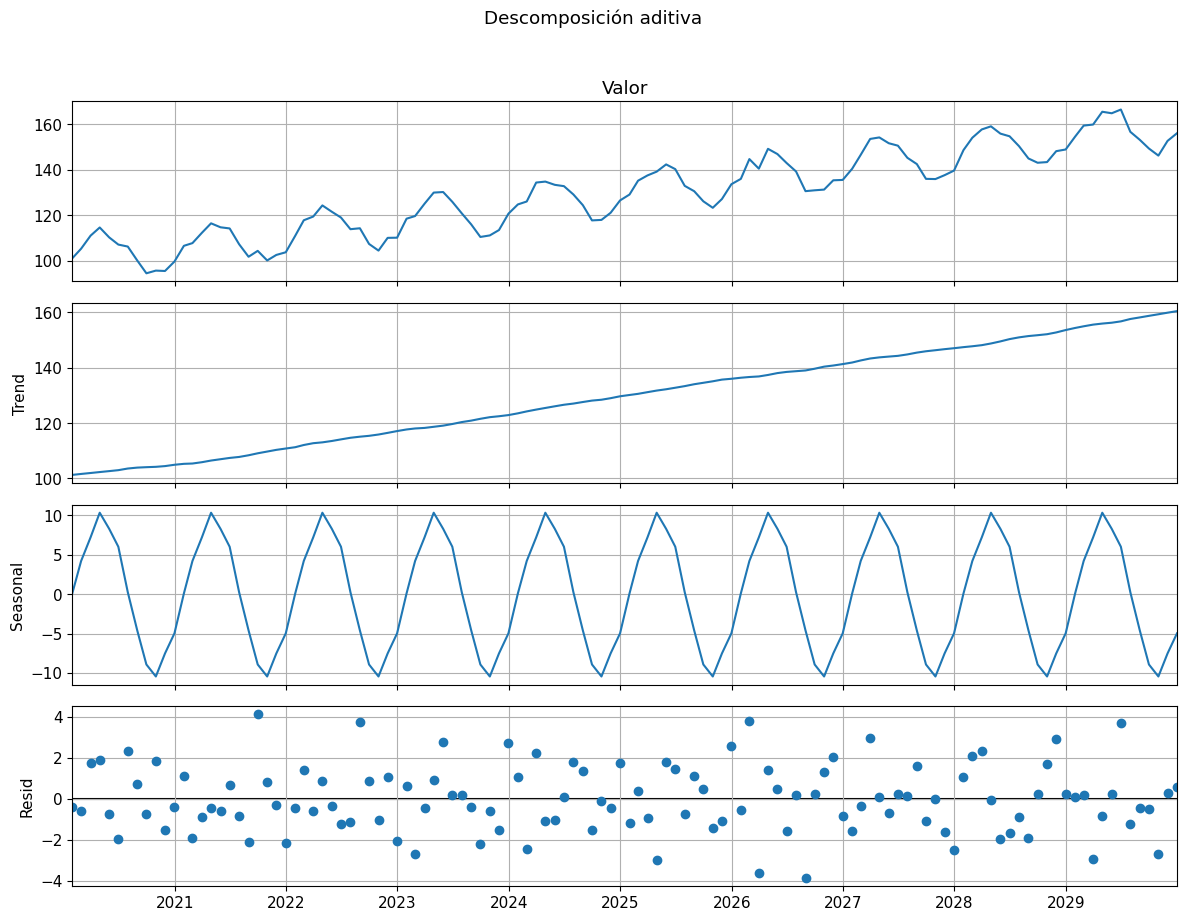

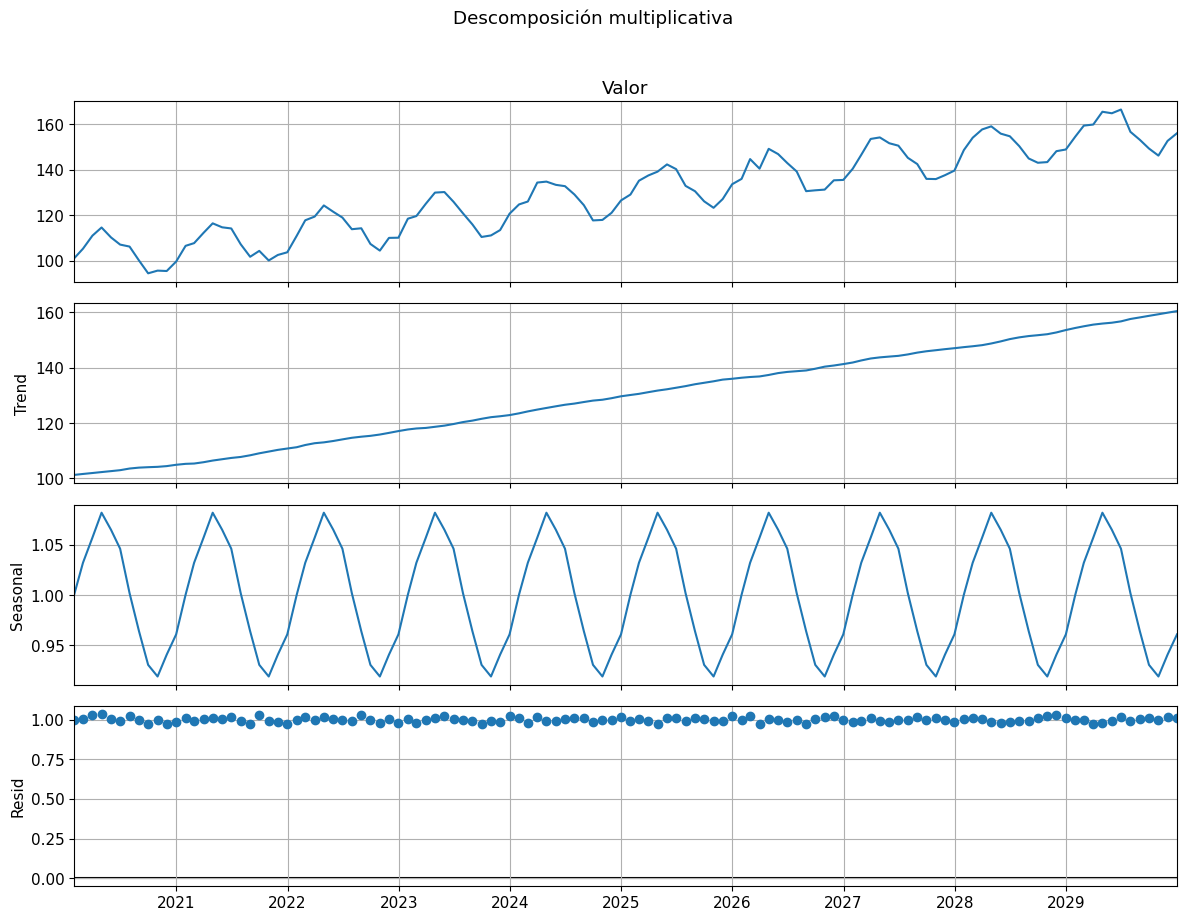

In [31]:
# ============================================================
# ELECCIÓN AUTOMÁTICA ENTRE MODELO ADITIVO Y MULTIPLICATIVO
#
# Requiere:
#     df["Valor"]
#
# Criterios:
# 1. Relación entre el nivel y la amplitud de cada ciclo.
# 2. Variabilidad normalizada de los residuos.
# 3. Autocorrelación residual mediante Ljung-Box.
#
# Interpretación:
# - Aditivo:
#       Y_t = T_t + S_t + R_t
#       La amplitud estacional es aproximadamente constante.
#
# - Multiplicativo:
#       Y_t = T_t * S_t * R_t
#       La amplitud estacional cambia proporcionalmente
#       al nivel de la serie.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox


def seleccionar_tipo_descomposicion(
    serie,
    periodo=12,
    alpha=0.05,
    graficar=True
):
    """
    Compara una descomposición aditiva y una multiplicativa.

    Parámetros
    ----------
    serie : pandas.Series
        Serie temporal con índice cronológico.

    periodo : int
        Número de observaciones por ciclo estacional.
        Ejemplo: 12 para datos mensuales con ciclo anual.

    alpha : float
        Nivel de significancia para Ljung-Box.

    graficar : bool
        Si es True, genera las gráficas diagnósticas.

    Retorna
    -------
    dict
        Resultados, métricas y modelo sugerido.
    """

    # --------------------------------------------------------
    # 1. Validar y limpiar la serie
    # --------------------------------------------------------

    if not isinstance(serie, pd.Series):
        serie = pd.Series(serie)

    serie = pd.to_numeric(
        serie,
        errors="coerce"
    ).dropna()

    if len(serie) < 2 * periodo:
        raise ValueError(
            f"Se necesitan al menos {2 * periodo} observaciones, "
            f"equivalentes a dos ciclos completos."
        )

    if periodo < 2:
        raise ValueError(
            "El período estacional debe ser mayor o igual a 2."
        )

    if (serie <= 0).any():
        raise ValueError(
            "La serie contiene valores iguales o menores que cero. "
            "La descomposición multiplicativa clásica requiere "
            "valores estrictamente positivos."
        )

    # --------------------------------------------------------
    # 2. Descomposición aditiva
    # --------------------------------------------------------

    modelo_aditivo = seasonal_decompose(
        serie,
        model="additive",
        period=periodo,
        extrapolate_trend="freq"
    )

    tendencia_aditiva = modelo_aditivo.trend
    estacional_aditiva = modelo_aditivo.seasonal
    residuo_aditivo = modelo_aditivo.resid

    # --------------------------------------------------------
    # 3. Descomposición multiplicativa
    # --------------------------------------------------------

    modelo_multiplicativo = seasonal_decompose(
        serie,
        model="multiplicative",
        period=periodo,
        extrapolate_trend="freq"
    )

    tendencia_multiplicativa = modelo_multiplicativo.trend
    estacional_multiplicativa = modelo_multiplicativo.seasonal
    residuo_multiplicativo = modelo_multiplicativo.resid

    # --------------------------------------------------------
    # 4. Normalizar los residuos para compararlos
    # --------------------------------------------------------
    #
    # Residual aditivo:
    #     idealmente alrededor de 0.
    #
    # Se divide por la tendencia para expresarlo como
    # desviación relativa respecto al nivel.
    #
    # Residual multiplicativo:
    #     idealmente alrededor de 1.
    #
    # Se aplica logaritmo:
    #     log(1) = 0
    #
    # De este modo ambos residuos quedan aproximadamente
    # centrados alrededor de cero y en escala relativa.
    # --------------------------------------------------------

    residuo_aditivo_normalizado = (
        residuo_aditivo
        / tendencia_aditiva.abs()
    ).replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    residuo_multiplicativo_log = (
        np.log(residuo_multiplicativo)
    ).replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    # Alinear longitudes para comparaciones coherentes
    longitud_comun = min(
        len(residuo_aditivo_normalizado),
        len(residuo_multiplicativo_log)
    )

    residuo_aditivo_normalizado = (
        residuo_aditivo_normalizado.iloc[-longitud_comun:]
    )

    residuo_multiplicativo_log = (
        residuo_multiplicativo_log.iloc[-longitud_comun:]
    )

    # --------------------------------------------------------
    # 5. Dispersión de los residuos
    # --------------------------------------------------------
    #
    # Un residual con menor dispersión relativa indica que
    # tendencia y estacionalidad explican mejor la serie.
    # --------------------------------------------------------

    rmse_aditivo = np.sqrt(
        np.mean(
            residuo_aditivo_normalizado ** 2
        )
    )

    rmse_multiplicativo = np.sqrt(
        np.mean(
            residuo_multiplicativo_log ** 2
        )
    )

    mae_aditivo = np.mean(
        np.abs(residuo_aditivo_normalizado)
    )

    mae_multiplicativo = np.mean(
        np.abs(residuo_multiplicativo_log)
    )

    # --------------------------------------------------------
    # 6. Prueba Ljung-Box
    # --------------------------------------------------------
    #
    # H0:
    # No existe autocorrelación conjunta en los residuos.
    #
    # p > alpha:
    # No se rechaza H0; los residuos son más compatibles
    # con ruido blanco.
    #
    # p <= alpha:
    # Queda autocorrelación sin explicar.
    # --------------------------------------------------------

    lag_ljungbox = min(
        2 * periodo,
        longitud_comun // 5
    )

    lag_ljungbox = max(
        1,
        lag_ljungbox
    )

    ljung_aditivo = acorr_ljungbox(
        residuo_aditivo_normalizado,
        lags=[lag_ljungbox],
        return_df=True
    )

    ljung_multiplicativo = acorr_ljungbox(
        residuo_multiplicativo_log,
        lags=[lag_ljungbox],
        return_df=True
    )

    p_aditivo = float(
        ljung_aditivo["lb_pvalue"].iloc[0]
    )

    p_multiplicativo = float(
        ljung_multiplicativo["lb_pvalue"].iloc[0]
    )

    # --------------------------------------------------------
    # 7. Relación entre nivel y amplitud por ciclo
    # --------------------------------------------------------
    #
    # Para cada ciclo se calcula:
    #
    # nivel = promedio del ciclo
    # amplitud = máximo - mínimo
    #
    # En una serie multiplicativa, la amplitud suele crecer
    # cuando aumenta el nivel.
    # --------------------------------------------------------

    cantidad_ciclos = len(serie) // periodo

    serie_ciclos = serie.iloc[
        :cantidad_ciclos * periodo
    ]

    tabla_ciclos = pd.DataFrame(
        {
            "Valor": serie_ciclos.to_numpy(),
            "Ciclo": np.repeat(
                np.arange(cantidad_ciclos),
                periodo
            )
        }
    )

    resumen_ciclos = (
        tabla_ciclos
        .groupby("Ciclo")["Valor"]
        .agg(
            Nivel_promedio="mean",
            Minimo="min",
            Maximo="max",
            Desviacion="std"
        )
    )

    resumen_ciclos["Amplitud"] = (
        resumen_ciclos["Maximo"]
        - resumen_ciclos["Minimo"]
    )

    resumen_ciclos["Amplitud_relativa"] = (
        resumen_ciclos["Amplitud"]
        / resumen_ciclos["Nivel_promedio"].abs()
    )

    if len(resumen_ciclos) >= 3:

        correlacion_nivel_amplitud = (
            resumen_ciclos["Nivel_promedio"]
            .corr(resumen_ciclos["Amplitud"])
        )

    else:

        correlacion_nivel_amplitud = np.nan

    # --------------------------------------------------------
    # 8. Coeficiente de variación de la amplitud relativa
    # --------------------------------------------------------
    #
    # Si amplitud/nivel permanece estable, existe evidencia
    # a favor del modelo multiplicativo.
    # --------------------------------------------------------

    media_amplitud_relativa = (
        resumen_ciclos["Amplitud_relativa"].mean()
    )

    if abs(media_amplitud_relativa) > 1e-12:

        cv_amplitud_relativa = (
            resumen_ciclos["Amplitud_relativa"].std()
            / abs(media_amplitud_relativa)
        )

    else:

        cv_amplitud_relativa = np.nan

    # --------------------------------------------------------
    # 9. Crear puntuaciones
    # --------------------------------------------------------
    #
    # Cada criterio entrega un punto al modelo favorecido.
    #
    # Criterio 1:
    # Menor RMSE residual normalizado.
    #
    # Criterio 2:
    # Mayor p-valor Ljung-Box.
    #
    # Criterio 3:
    # Correlación alta entre nivel y amplitud favorece
    # multiplicativo; baja favorece aditivo.
    # --------------------------------------------------------

    puntos_aditivo = 0
    puntos_multiplicativo = 0

    razones_aditivo = []
    razones_multiplicativo = []

    # Criterio de dispersión residual
    if rmse_aditivo < rmse_multiplicativo:

        puntos_aditivo += 1

        razones_aditivo.append(
            "presenta menor dispersión residual normalizada"
        )

    elif rmse_multiplicativo < rmse_aditivo:

        puntos_multiplicativo += 1

        razones_multiplicativo.append(
            "presenta menor dispersión residual normalizada"
        )

    # Criterio de autocorrelación residual
    if p_aditivo > p_multiplicativo:

        puntos_aditivo += 1

        razones_aditivo.append(
            "presenta residuos con menor evidencia de autocorrelación"
        )

    elif p_multiplicativo > p_aditivo:

        puntos_multiplicativo += 1

        razones_multiplicativo.append(
            "presenta residuos con menor evidencia de autocorrelación"
        )

    # Criterio nivel-amplitud
    if not np.isnan(correlacion_nivel_amplitud):

        if correlacion_nivel_amplitud >= 0.60:

            puntos_multiplicativo += 1

            razones_multiplicativo.append(
                "la amplitud estacional aumenta con el nivel"
            )

        elif correlacion_nivel_amplitud <= 0.30:

            puntos_aditivo += 1

            razones_aditivo.append(
                "la amplitud estacional es poco dependiente del nivel"
            )

    # --------------------------------------------------------
    # 10. Determinar conclusión
    # --------------------------------------------------------

    if puntos_aditivo >= 2 and puntos_aditivo > puntos_multiplicativo:

        modelo_sugerido = "ADITIVO"

        nivel_confianza = (
            "alta"
            if puntos_aditivo == 3
            else "moderada"
        )

    elif (
        puntos_multiplicativo >= 2
        and puntos_multiplicativo > puntos_aditivo
    ):

        modelo_sugerido = "MULTIPLICATIVO"

        nivel_confianza = (
            "alta"
            if puntos_multiplicativo == 3
            else "moderada"
        )

    else:

        modelo_sugerido = "NO CONCLUYENTE"

        nivel_confianza = "baja"

    # --------------------------------------------------------
    # 11. Tabla comparativa
    # --------------------------------------------------------

    resultados = pd.DataFrame(
        {
            "Modelo": [
                "Aditivo",
                "Multiplicativo"
            ],
            "MAE residual normalizado": [
                mae_aditivo,
                mae_multiplicativo
            ],
            "RMSE residual normalizado": [
                rmse_aditivo,
                rmse_multiplicativo
            ],
            f"p-valor Ljung-Box lag {lag_ljungbox}": [
                p_aditivo,
                p_multiplicativo
            ],
            "¿Residual compatible con ruido blanco?": [
                "Sí" if p_aditivo > alpha else "No",
                "Sí" if p_multiplicativo > alpha else "No"
            ],
            "Puntos": [
                puntos_aditivo,
                puntos_multiplicativo
            ]
        }
    )

    # --------------------------------------------------------
    # 12. Mostrar resultados
    # --------------------------------------------------------

    print("=" * 80)
    print("COMPARACIÓN: MODELO ADITIVO VS. MULTIPLICATIVO")
    print("=" * 80)

    display(
        resultados.round(6)
    )

    print("\n" + "=" * 80)
    print("RELACIÓN ENTRE NIVEL Y AMPLITUD")
    print("=" * 80)

    display(
        resumen_ciclos.round(4)
    )

    print(
        "\nCorrelación entre nivel y amplitud: "
        f"{correlacion_nivel_amplitud:.4f}"
    )

    print(
        "Coeficiente de variación de la amplitud relativa: "
        f"{cv_amplitud_relativa:.4f}"
    )

    print("\n" + "=" * 80)
    print("CONCLUSIÓN AUTOMÁTICA")
    print("=" * 80)

    print(
        f"Modelo sugerido: {modelo_sugerido}"
    )

    print(
        f"Nivel de evidencia: {nivel_confianza}"
    )

    print(
        f"Puntuación aditiva: "
        f"{puntos_aditivo}/3"
    )

    print(
        f"Puntuación multiplicativa: "
        f"{puntos_multiplicativo}/3"
    )

    if modelo_sugerido == "ADITIVO":

        print("""
La evidencia favorece una estructura aditiva:

Y_t = T_t + S_t + R_t

La amplitud de las fluctuaciones estacionales se mantiene
relativamente constante frente a los cambios en el nivel.
""")

        if razones_aditivo:

            print("Razones:")

            for razon in razones_aditivo:

                print(f"- {razon}.")

    elif modelo_sugerido == "MULTIPLICATIVO":

        print("""
La evidencia favorece una estructura multiplicativa:

Y_t = T_t × S_t × R_t

La amplitud de las fluctuaciones estacionales cambia
proporcionalmente al nivel de la serie.
""")

        if razones_multiplicativo:

            print("Razones:")

            for razon in razones_multiplicativo:

                print(f"- {razon}.")

    else:

        print("""
Los criterios no coinciden suficientemente.

No puede concluirse con claridad que la serie sea aditiva
o multiplicativa. Deben revisarse las gráficas, los residuos,
posibles cambios estructurales y una transformación logarítmica.
""")

    # --------------------------------------------------------
    # 13. Gráficas diagnósticas
    # --------------------------------------------------------

    if graficar:

        # Serie original
        plt.figure(figsize=(14, 5))

        plt.plot(
            serie.index,
            serie,
            linewidth=1.7
        )

        plt.title(
            "Serie temporal original"
        )

        plt.xlabel("Tiempo")
        plt.ylabel("Valor")
        plt.tight_layout()
        plt.show()

        # Nivel frente a amplitud
        plt.figure(figsize=(8, 5))

        plt.scatter(
            resumen_ciclos["Nivel_promedio"],
            resumen_ciclos["Amplitud"]
        )

        if len(resumen_ciclos) >= 2:

            coeficientes = np.polyfit(
                resumen_ciclos["Nivel_promedio"],
                resumen_ciclos["Amplitud"],
                1
            )

            valores_x = np.linspace(
                resumen_ciclos["Nivel_promedio"].min(),
                resumen_ciclos["Nivel_promedio"].max(),
                100
            )

            valores_y = (
                coeficientes[0] * valores_x
                + coeficientes[1]
            )

            plt.plot(
                valores_x,
                valores_y,
                linestyle="--"
            )

        plt.title(
            "Relación entre nivel y amplitud estacional"
        )

        plt.xlabel(
            "Nivel promedio del ciclo"
        )

        plt.ylabel(
            "Amplitud máxima-mínima del ciclo"
        )

        plt.tight_layout()
        plt.show()

        # Residuos normalizados
        plt.figure(figsize=(14, 5))

        plt.plot(
            residuo_aditivo_normalizado.index,
            residuo_aditivo_normalizado,
            label="Residual aditivo normalizado"
        )

        plt.plot(
            residuo_multiplicativo_log.index,
            residuo_multiplicativo_log,
            label="Log residual multiplicativo",
            alpha=0.8
        )

        plt.axhline(
            0,
            linestyle="--",
            linewidth=1
        )

        plt.title(
            "Comparación de residuos en escala relativa"
        )

        plt.xlabel("Tiempo")
        plt.ylabel("Residual normalizado")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Descomposición aditiva
        figura_aditiva = modelo_aditivo.plot()

        figura_aditiva.set_size_inches(
            12,
            9
        )

        figura_aditiva.suptitle(
            "Descomposición aditiva",
            y=1.02
        )

        plt.tight_layout()
        plt.show()

        # Descomposición multiplicativa
        figura_multiplicativa = (
            modelo_multiplicativo.plot()
        )

        figura_multiplicativa.set_size_inches(
            12,
            9
        )

        figura_multiplicativa.suptitle(
            "Descomposición multiplicativa",
            y=1.02
        )

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # 14. Retornar resultados
    # --------------------------------------------------------

    return {
        "modelo_sugerido": modelo_sugerido,
        "nivel_evidencia": nivel_confianza,
        "tabla_resultados": resultados,
        "resumen_ciclos": resumen_ciclos,
        "correlacion_nivel_amplitud":
            correlacion_nivel_amplitud,
        "cv_amplitud_relativa":
            cv_amplitud_relativa,
        "modelo_aditivo": modelo_aditivo,
        "modelo_multiplicativo":
            modelo_multiplicativo,
        "residuo_aditivo_normalizado":
            residuo_aditivo_normalizado,
        "residuo_multiplicativo_log":
            residuo_multiplicativo_log
    }


# ============================================================
# EJECUTAR SOBRE LA SERIE
# ============================================================

comparacion_modelos = seleccionar_tipo_descomposicion(
    serie=df["Valor"],
    periodo=12,
    alpha=0.05,
    graficar=True
)

## 16. Reconstrucción de la serie
Se suman los componentes estimados para comprobar que reproducen la serie original.

Error absoluto máximo: 0.000000000000
Error absoluto medio: 0.000000000000


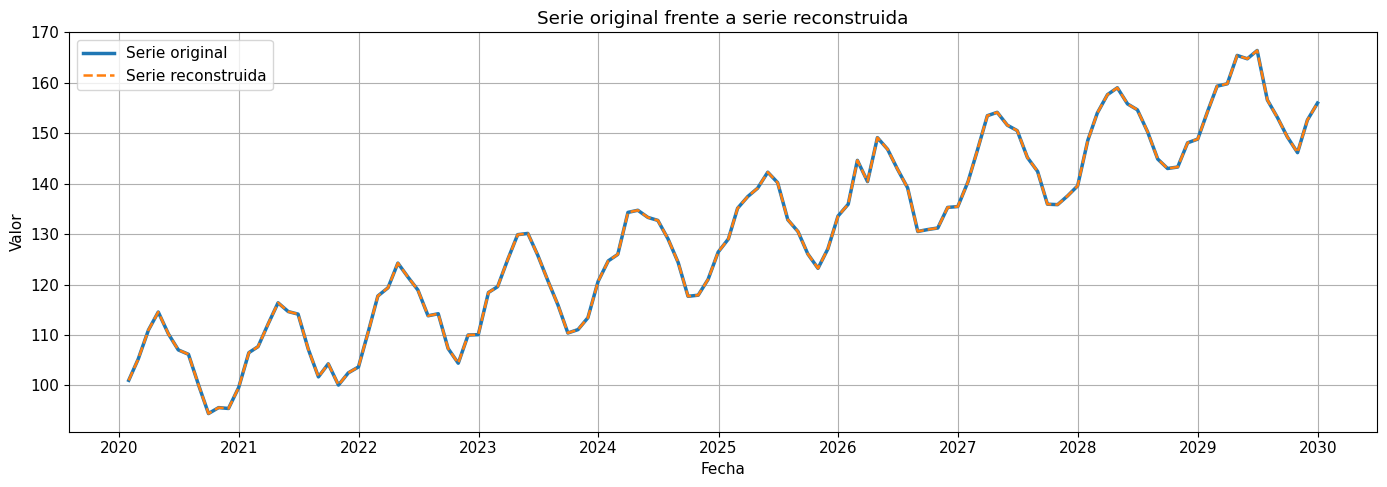

In [29]:
df["Serie_reconstruida"] = (
    df["Nivel_estimado"]
    + df["Tendencia_lineal_estimada"]
    + df["Estacionalidad_estimada"]
    + df["Ruido_estimado"]
)

df["Error_reconstruccion"] = df["Valor"] - df["Serie_reconstruida"]

print(f"Error absoluto máximo: {df['Error_reconstruccion'].abs().max():.12f}")
print(f"Error absoluto medio: {df['Error_reconstruccion'].abs().mean():.12f}")

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Valor"], linewidth=2.5, label="Serie original")
plt.plot(df.index, df["Serie_reconstruida"], linestyle="--", linewidth=1.8, label="Serie reconstruida")
plt.title("Serie original frente a serie reconstruida")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()

## 17. Anatomía completa de la serie
En una sola figura se presentan la serie observada y los cuatro componentes estimados.

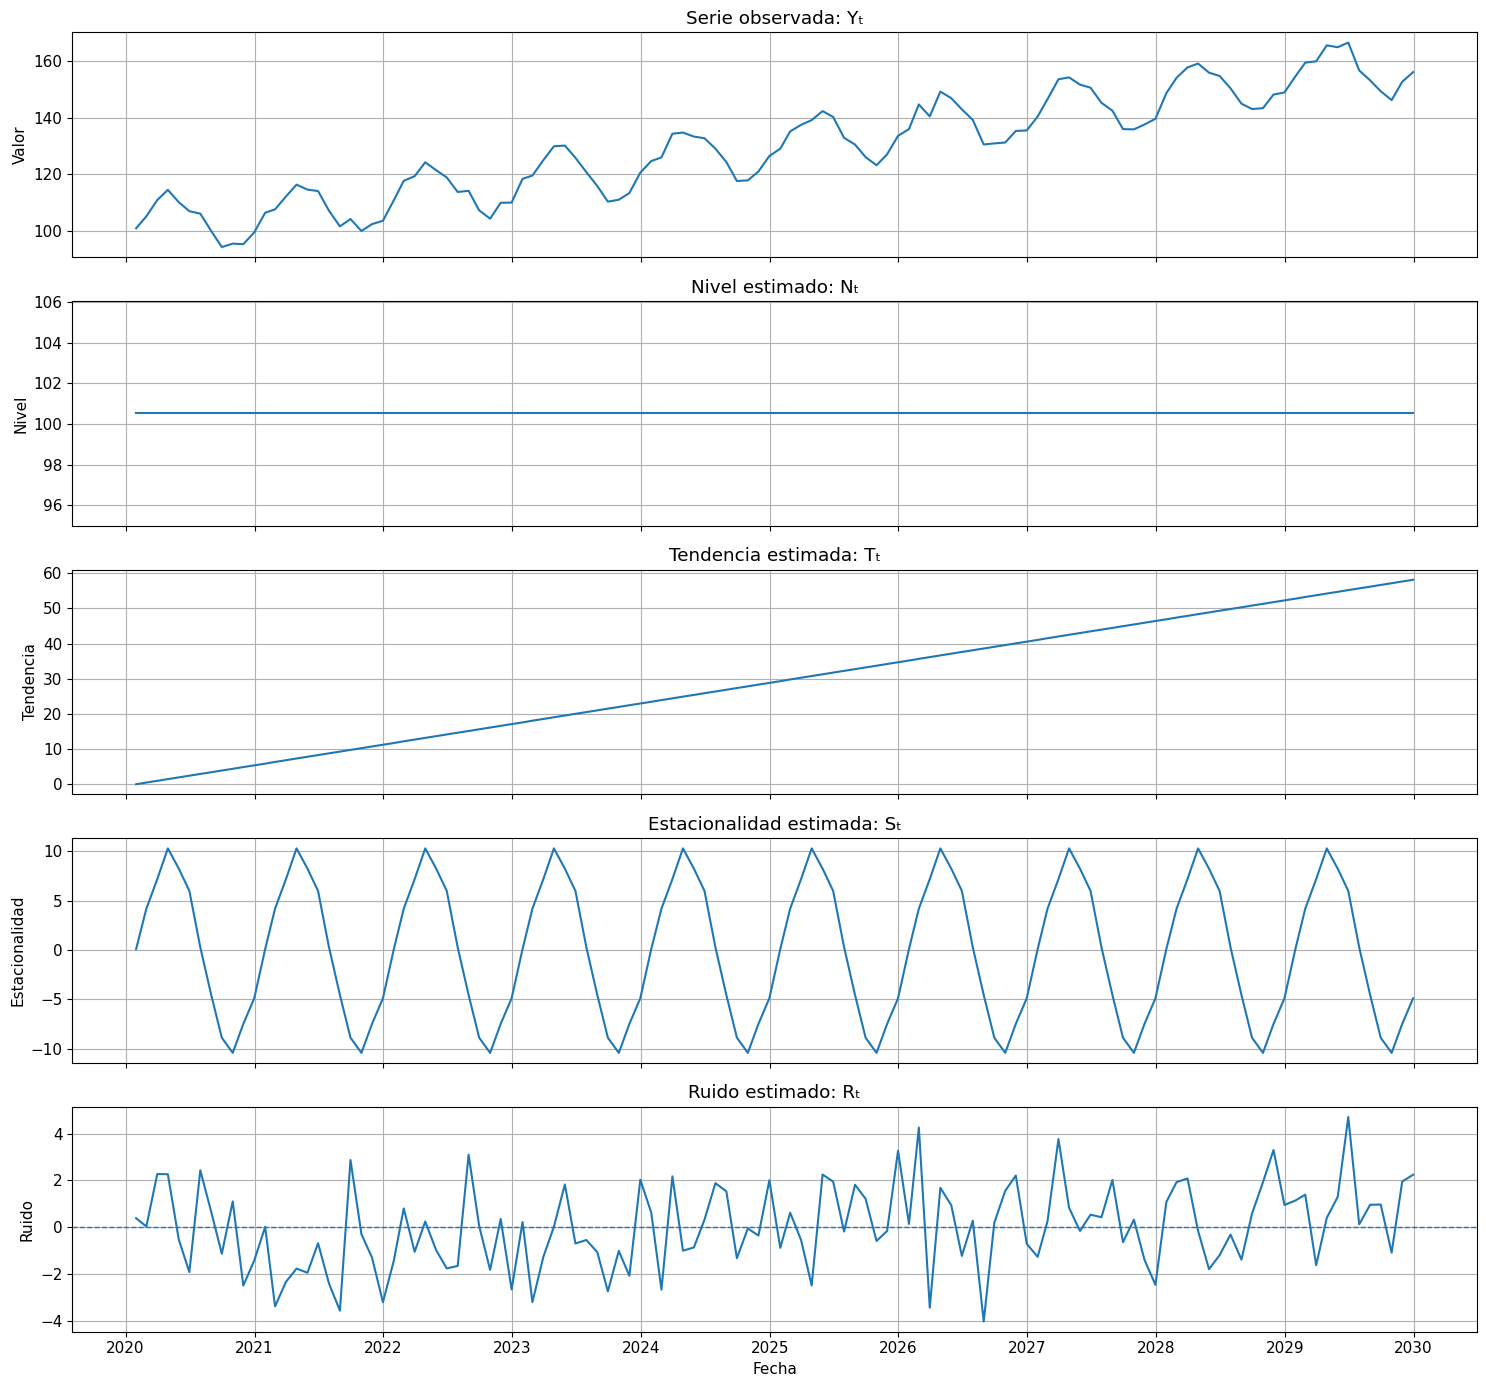

In [17]:
fig, axes = plt.subplots(5, 1, figsize=(15, 14), sharex=True)

axes[0].plot(df.index, df["Valor"])
axes[0].set_title("Serie observada: Yₜ")
axes[0].set_ylabel("Valor")

axes[1].plot(df.index, df["Nivel_estimado"])
axes[1].set_title("Nivel estimado: Nₜ")
axes[1].set_ylabel("Nivel")

axes[2].plot(df.index, df["Tendencia_lineal_estimada"])
axes[2].set_title("Tendencia estimada: Tₜ")
axes[2].set_ylabel("Tendencia")

axes[3].plot(df.index, df["Estacionalidad_estimada"])
axes[3].set_title("Estacionalidad estimada: Sₜ")
axes[3].set_ylabel("Estacionalidad")

axes[4].plot(df.index, df["Ruido_estimado"])
axes[4].axhline(0, linestyle="--", linewidth=1)
axes[4].set_title("Ruido estimado: Rₜ")
axes[4].set_xlabel("Fecha")
axes[4].set_ylabel("Ruido")

plt.tight_layout()
plt.show()

## 18. Descomposición STL
STL utiliza suavizamiento LOESS y puede reducir la influencia de valores atípicos mediante `robust=True`.

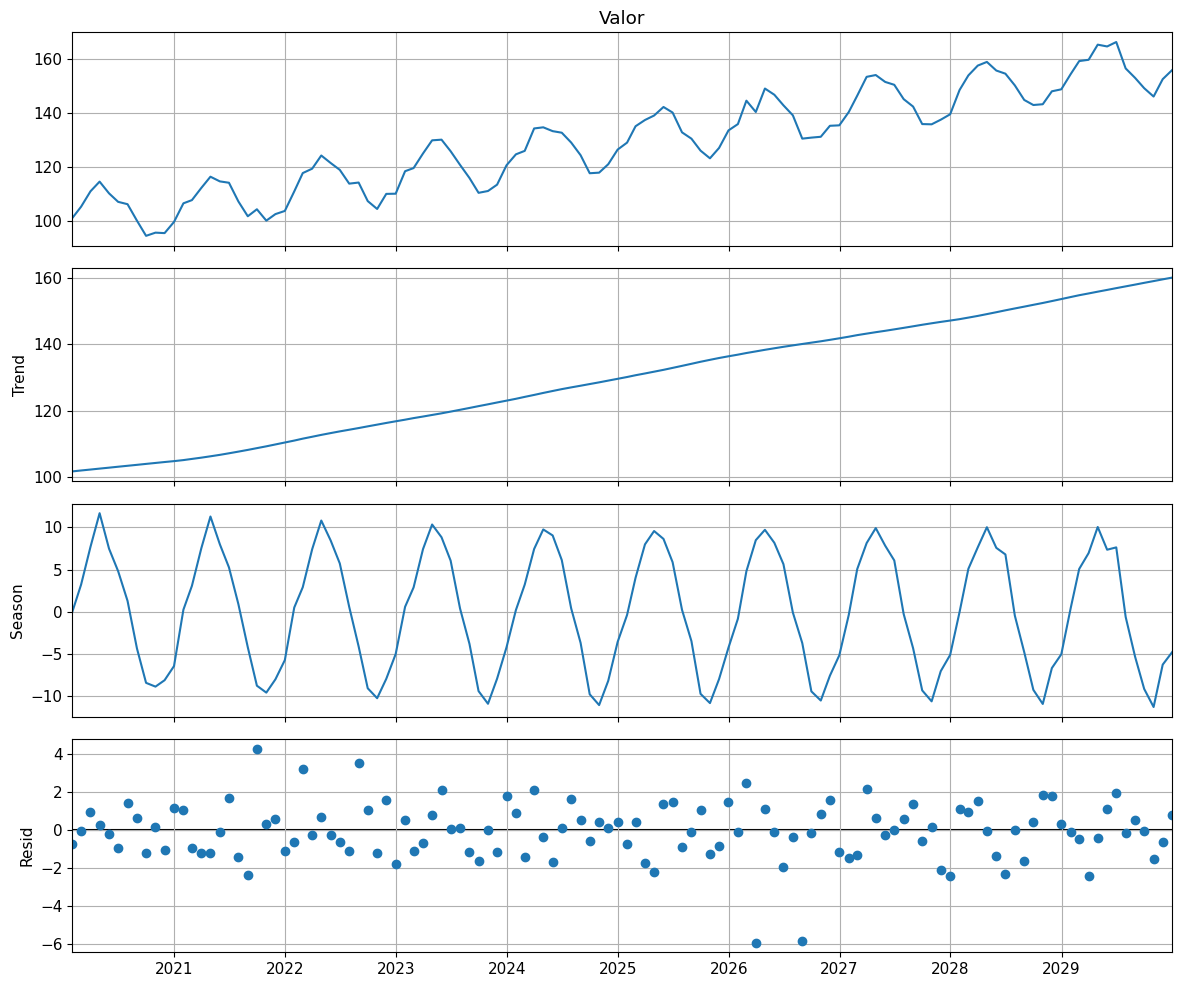

In [18]:
stl = STL(df["Valor"], period=12, robust=True)
resultado_stl = stl.fit()

fig = resultado_stl.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

df["STL_Trend"] = resultado_stl.trend
df["STL_Seasonal"] = resultado_stl.seasonal
df["STL_Residual"] = resultado_stl.resid

## 19. Comparación entre descomposición clásica y STL
Se comparan tendencia, estacionalidad y residuos obtenidos por ambos métodos.

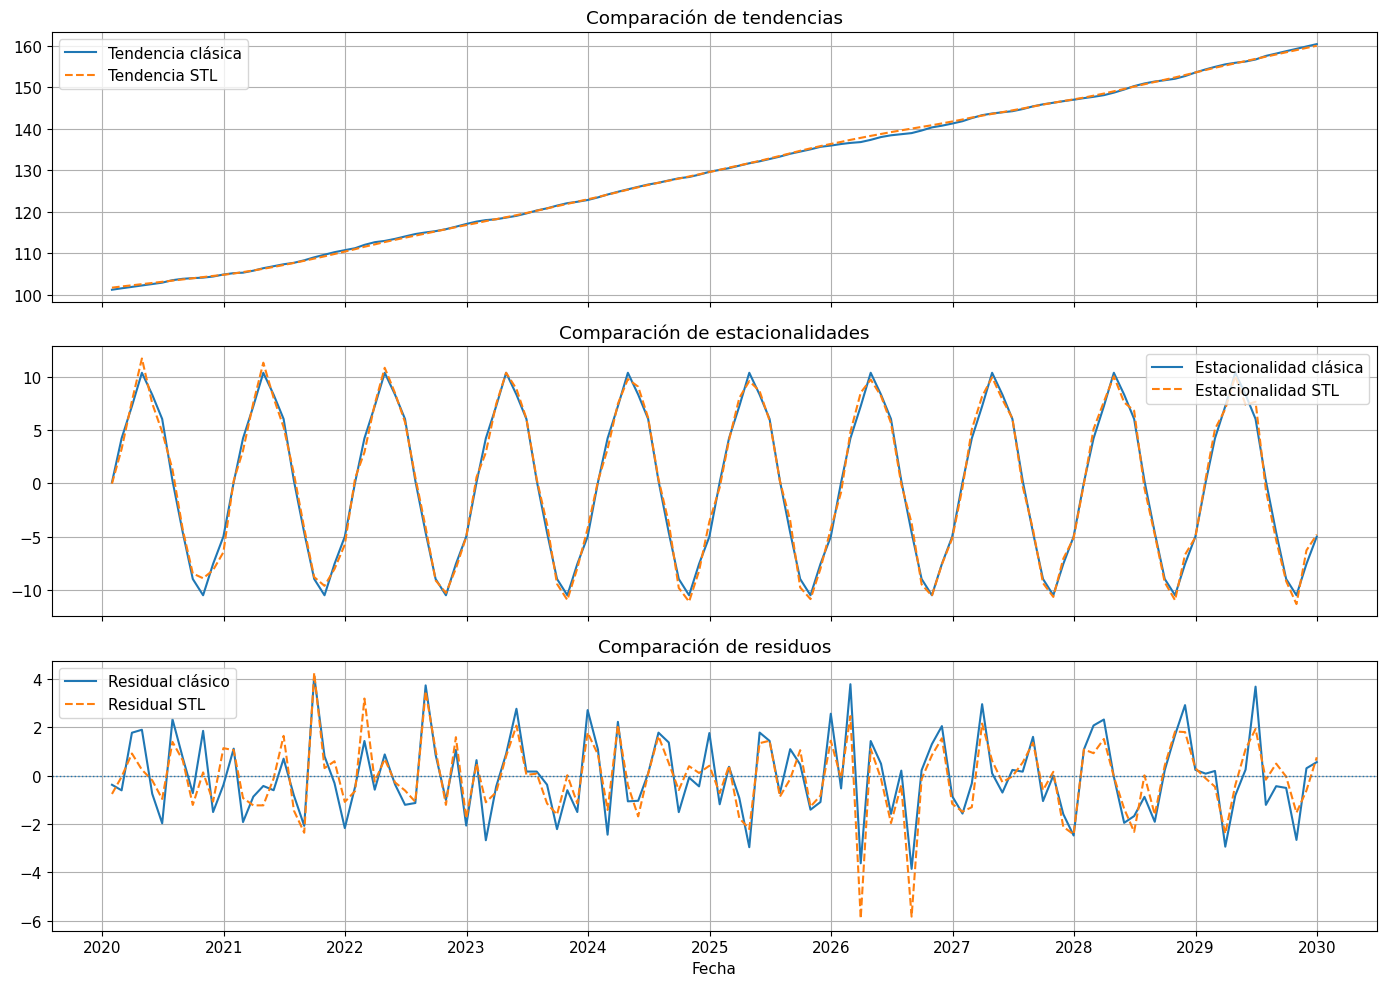

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df["Clasica_Trend"], label="Tendencia clásica")
axes[0].plot(df.index, df["STL_Trend"], linestyle="--", label="Tendencia STL")
axes[0].set_title("Comparación de tendencias")
axes[0].legend()

axes[1].plot(df.index, df["Clasica_Seasonal"], label="Estacionalidad clásica")
axes[1].plot(df.index, df["STL_Seasonal"], linestyle="--", label="Estacionalidad STL")
axes[1].set_title("Comparación de estacionalidades")
axes[1].legend()

axes[2].plot(df.index, df["Clasica_Residual"], label="Residual clásico")
axes[2].plot(df.index, df["STL_Residual"], linestyle="--", label="Residual STL")
axes[2].axhline(0, linestyle=":", linewidth=1)
axes[2].set_title("Comparación de residuos")
axes[2].legend()
axes[2].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

## 20. Conclusiones automáticas
Se resumen el nivel, la tendencia, la estacionalidad y las propiedades básicas del ruido estimado.

In [20]:
direccion = "creciente" if pendiente_estimada > 0 else "decreciente" if pendiente_estimada < 0 else "estable"

mes_maximo = tabla_estacionalidad["Indice_estacional"].idxmax()
mes_minimo = tabla_estacionalidad["Indice_estacional"].idxmin()

nombre_mes_maximo = tabla_estacionalidad.loc[mes_maximo, "Mes"]
nombre_mes_minimo = tabla_estacionalidad.loc[mes_minimo, "Mes"]
indice_maximo = tabla_estacionalidad.loc[mes_maximo, "Indice_estacional"]
indice_minimo = tabla_estacionalidad.loc[mes_minimo, "Indice_estacional"]

print(f"""
Nivel inicial estimado: {intercepto_estimado:.2f}
Tendencia: {direccion}
Pendiente mensual: {pendiente_estimada:.4f}
Crecimiento anual aproximado: {pendiente_estimada * 12:.2f}
Mayor efecto estacional: {nombre_mes_maximo} ({indice_maximo:.2f})
Menor efecto estacional: {nombre_mes_minimo} ({indice_minimo:.2f})
Media del ruido: {media_ruido:.6f}
Desviación estándar del ruido: {desviacion_ruido:.4f}
""")


Nivel inicial estimado: 100.52
Tendencia: creciente
Pendiente mensual: 0.4886
Crecimiento anual aproximado: 5.86
Mayor efecto estacional: Abril (10.30)
Menor efecto estacional: Octubre (-10.43)
Media del ruido: -0.000000
Desviación estándar del ruido: 1.7879



## 21. DataFrame final
Se muestran las primeras observaciones con todos los componentes calculados.

In [21]:
columnas_finales = [
    "Valor",
    "Nivel_estimado",
    "Tendencia_lineal_estimada",
    "Estacionalidad_estimada",
    "Ruido_estimado",
    "Serie_reconstruida",
    "Clasica_Trend",
    "Clasica_Seasonal",
    "Clasica_Residual",
    "STL_Trend",
    "STL_Seasonal",
    "STL_Residual"
]

display(df[columnas_finales].head(20).round(4))

,Valor,Nivel_estimado,Tendencia_lineal_estimada,Estacionalidad_estimada,Ruido_estimado,Serie_reconstruida,Clasica_Trend,Clasica_Seasonal,Clasica_Residual,STL_Trend,STL_Seasonal,STL_Residual
Fecha,,,,,,,,,,,,
2020-01-31,100.9934,100.5214,0.0000,0.0909,0.3811,100.9934,101.2709,0.1002,-0.3777,101.7693,-0.0177,-0.7582
2020-02-29,105.2235,100.5214,0.4886,4.1870,0.0264,105.2235,101.6123,4.2195,-0.6083,102.0513,3.2187,-0.0465
2020-03-31,110.9556,100.5214,0.9772,7.1873,2.2698,110.9556,101.9537,7.2244,1.7776,102.3329,7.7055,0.9172
2020-04-30,114.5461,100.5214,1.4657,10.2981,2.2608,114.5461,102.2951,10.3503,1.9007,102.6148,11.6865,0.2448
2020-05-31,110.1919,100.5214,1.9543,8.2472,-0.5310,110.1919,102.6365,8.3047,-0.7492,102.8970,7.4872,-0.1922
2020-06-30,107.0317,100.5214,2.4429,5.9895,-1.9221,107.0317,102.9779,6.0279,-1.9741,103.1797,4.8174,-0.9654
2020-07-31,106.1584,100.5214,2.9315,0.2774,2.4282,106.1584,103.5707,0.2536,2.3341,103.4628,1.2971,1.3986
2020-08-31,100.0349,100.5214,3.4200,-4.5602,0.6536,100.0349,103.9015,-4.6008,0.7341,103.7465,-4.3408,0.6292
2020-09-30,94.4008,100.5214,3.9086,-8.8916,-1.1377,94.4008,104.0559,-8.9296,-0.7255,104.0306,-8.4165,-1.2132


## **Función de correlación y de autocorrelación**

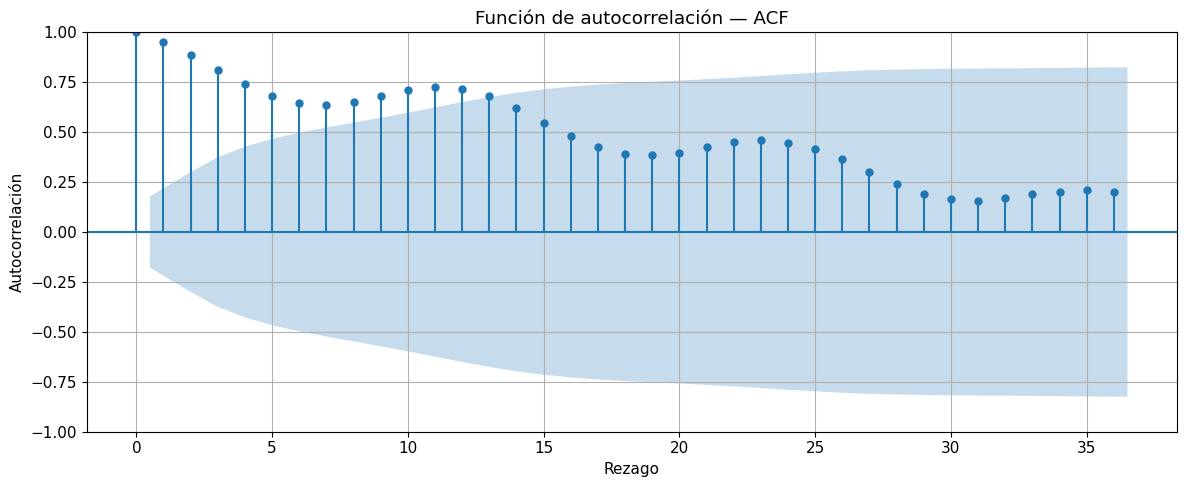

VALORES DE LA FUNCIÓN DE AUTOCORRELACIÓN


,Rezago,Autocorrelación
0,0,1.0000
1,1,0.9524
2,2,0.8873
3,3,0.8127
4,4,0.7393
5,5,0.6813
6,6,0.6441
7,7,0.6369
8,8,0.6524
9,9,0.6816


AUTOCORRELACIONES EN REZAGOS SELECCIONADOS


,Rezago,Autocorrelación
1,1,0.9524
2,2,0.8873
3,3,0.8127
6,6,0.6441
12,12,0.7176
18,18,0.3925
24,24,0.4464
36,36,0.2018


INTERPRETACIÓN
Autocorrelación en el rezago 1: 0.9709
Autocorrelación en el rezago 12: 0.9876

Existe una dependencia temporal fuerte entre el valor actual y el período inmediatamente anterior.
La autocorrelación alta en el rezago 12 constituye evidencia de un patrón estacional anual.

Lectura de la gráfica:

- El rezago 0 siempre tiene autocorrelación igual a 1 porque
  la serie se compara consigo misma.

- Las barras que superan las bandas de confianza indican
  autocorrelaciones estadísticamente relevantes.

- Una ACF que disminuye lentamente puede indicar tendencia
  o falta de estacionariedad.

- Picos en los rezagos 12, 24 y 36 pueden indicar que un
  patrón anual se repite en una serie mensual.



In [32]:
# ============================================================
# FUNCIÓN DE AUTOCORRELACIÓN (ACF)
# ============================================================
#
# La ACF mide la relación entre el valor actual Y_t
# y sus valores pasados Y_(t-k).
#
# Ejemplos:
# Lag 1  -> relación entre Y_t y Y_(t-1)
# Lag 12 -> relación entre Y_t y Y_(t-12)
#
# En datos mensuales, un pico en el rezago 12 puede indicar
# estacionalidad anual.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf


# ------------------------------------------------------------
# 1. Preparar la serie
# ------------------------------------------------------------

serie = df["Valor"].dropna().astype(float)


# ------------------------------------------------------------
# 2. Gráfica de la función de autocorrelación
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    serie,
    lags=36,
    alpha=0.05,
    fft=True,
    ax=ax
)

ax.set_title("Función de autocorrelación — ACF")
ax.set_xlabel("Rezago")
ax.set_ylabel("Autocorrelación")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Calcular numéricamente las autocorrelaciones
# ------------------------------------------------------------

valores_acf = acf(
    serie,
    nlags=36,
    fft=True
)

tabla_acf = pd.DataFrame(
    {
        "Rezago": range(len(valores_acf)),
        "Autocorrelación": valores_acf
    }
)


print("=" * 70)
print("VALORES DE LA FUNCIÓN DE AUTOCORRELACIÓN")
print("=" * 70)

display(
    tabla_acf.round(4)
)


# ------------------------------------------------------------
# 4. Mostrar rezagos de interés
# ------------------------------------------------------------

rezagos_interes = [1, 2, 3, 6, 12, 18, 24, 36]

tabla_rezagos = tabla_acf[
    tabla_acf["Rezago"].isin(rezagos_interes)
]

print("=" * 70)
print("AUTOCORRELACIONES EN REZAGOS SELECCIONADOS")
print("=" * 70)

display(
    tabla_rezagos.round(4)
)


# ------------------------------------------------------------
# 5. Interpretación automática
# ------------------------------------------------------------

acf_lag_1 = serie.autocorr(lag=1)
acf_lag_12 = serie.autocorr(lag=12)

print("=" * 70)
print("INTERPRETACIÓN")
print("=" * 70)

print(f"Autocorrelación en el rezago 1: {acf_lag_1:.4f}")
print(f"Autocorrelación en el rezago 12: {acf_lag_12:.4f}")

if abs(acf_lag_1) >= 0.70:
    print(
        "\nExiste una dependencia temporal fuerte entre el valor "
        "actual y el período inmediatamente anterior."
    )

elif abs(acf_lag_1) >= 0.40:
    print(
        "\nExiste una dependencia temporal moderada con el "
        "período inmediatamente anterior."
    )

else:
    print(
        "\nLa dependencia temporal con el período anterior "
        "es débil."
    )


if acf_lag_12 >= 0.60:
    print(
        "La autocorrelación alta en el rezago 12 constituye "
        "evidencia de un patrón estacional anual."
    )

elif acf_lag_12 >= 0.30:
    print(
        "Existe evidencia moderada de una posible "
        "estacionalidad anual."
    )

else:
    print(
        "No se observa una autocorrelación suficientemente "
        "alta en el rezago 12 para concluir estacionalidad anual."
    )


print("""
Lectura de la gráfica:

- El rezago 0 siempre tiene autocorrelación igual a 1 porque
  la serie se compara consigo misma.

- Las barras que superan las bandas de confianza indican
  autocorrelaciones estadísticamente relevantes.

- Una ACF que disminuye lentamente puede indicar tendencia
  o falta de estacionariedad.

- Picos en los rezagos 12, 24 y 36 pueden indicar que un
  patrón anual se repite en una serie mensual.
""")

Número de observaciones: 120
Número de rezagos utilizados: 36


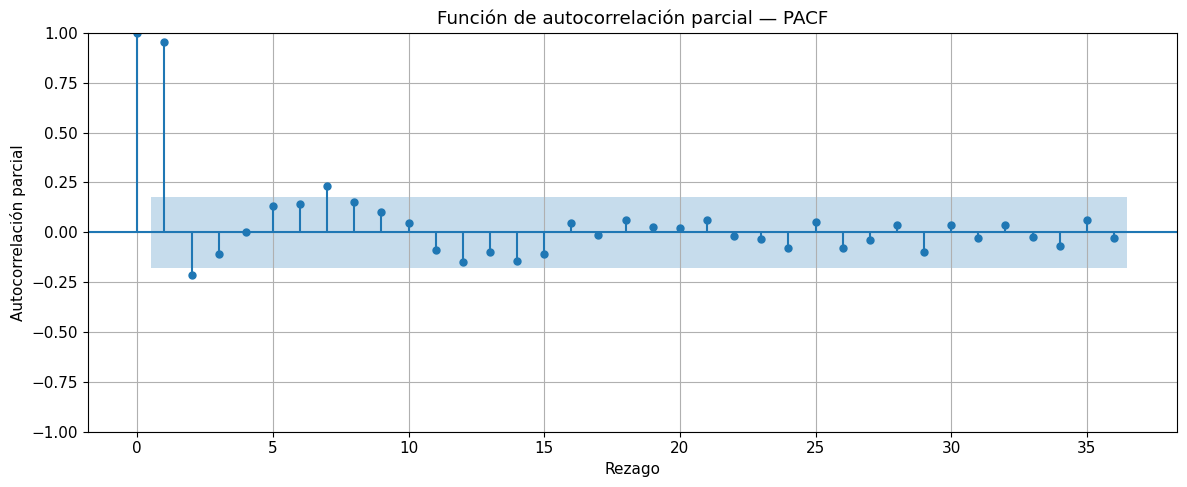

VALORES DE LA FUNCIÓN DE AUTOCORRELACIÓN PARCIAL


,Rezago,Autocorrelación parcial
0,0,1.0000
1,1,0.9524
2,2,-0.2130
3,3,-0.1069
4,4,0.0017
5,5,0.1308
6,6,0.1437
7,7,0.2329
8,8,0.1522
9,9,0.1016


PACF EN REZAGOS SELECCIONADOS


,Rezago,Autocorrelación parcial
1,1,0.9524
2,2,-0.2130
3,3,-0.1069
6,6,0.1437
12,12,-0.1494
18,18,0.0606
24,24,-0.0777
36,36,-0.0289


Límite aproximado de significancia al 95 %: ±0.1789
REZAGOS PACF SIGNIFICATIVOS


,Rezago,Autocorrelación parcial,Significativo
1,1,0.9524,True
2,2,-0.2130,True
7,7,0.2329,True


INTERPRETACIÓN DE LA PACF
Rezagos PACF significativos detectados:
[1, 2, 7]

La secuencia inicial de rezagos significativos sugiere como punto de partida un modelo AR(2).

El rezago 12 no presenta una PACF significativa o no pudo evaluarse.

Lectura de la gráfica:

- El rezago 0 siempre vale 1 porque la serie se compara
  consigo misma.

- Las barras que superan las bandas de confianza indican
  relaciones parciales estadísticamente relevantes.

- Un pico significativo en el rezago 1 puede sugerir AR(1).

- Picos significativos en los rezagos 1 y 2, seguidos de
  valores no significativos, pueden sugerir AR(2).

- Un pico en el rezago 12, para datos mensuales, puede
  indicar una dependencia estacional anual.

Importante:

La PACF debe analizarse sobre una serie estacionaria.
Si la serie tiene tendencia o estacionalidad fuerte, primero
conviene diferenciarla o eliminar esos componentes.



In [34]:
# ============================================================
# FUNCIÓN DE AUTOCORRELACIÓN PARCIAL (PACF)
# ============================================================
#
# La PACF mide la relación directa entre el valor actual Y_t
# y un valor pasado Y_(t-k), eliminando el efecto de los
# rezagos intermedios.
#
# Ejemplos:
#
# PACF en lag 1:
# relación directa entre Y_t y Y_(t-1)
#
# PACF en lag 2:
# relación directa entre Y_t y Y_(t-2),
# controlando el efecto de Y_(t-1)
#
# La PACF se utiliza principalmente para orientar el orden p
# de un modelo autorregresivo AR(p).
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf


# ------------------------------------------------------------
# 1. Preparar la serie
# ------------------------------------------------------------

serie = df["Valor"].dropna().astype(float)


# ------------------------------------------------------------
# 2. Determinar un número válido de rezagos
# ------------------------------------------------------------
#
# Para PACF, statsmodels requiere que el número de rezagos sea
# menor que aproximadamente la mitad de las observaciones.
# ------------------------------------------------------------

max_lags_permitido = max(
    1,
    len(serie) // 2 - 1
)

lags_solicitados = 36

lags_utilizados = min(
    lags_solicitados,
    max_lags_permitido
)

print(
    f"Número de observaciones: {len(serie)}"
)

print(
    f"Número de rezagos utilizados: {lags_utilizados}"
)


# ------------------------------------------------------------
# 3. Gráfica de la PACF
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

plot_pacf(
    serie,
    lags=lags_utilizados,
    alpha=0.05,
    method="ywm",
    ax=ax
)

ax.set_title(
    "Función de autocorrelación parcial — PACF"
)

ax.set_xlabel("Rezago")

ax.set_ylabel("Autocorrelación parcial")

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 4. Calcular numéricamente los valores PACF
# ------------------------------------------------------------
#
# method="ywm" utiliza el método de Yule-Walker modificado.
# ------------------------------------------------------------

valores_pacf = pacf(
    serie,
    nlags=lags_utilizados,
    method="ywm"
)

tabla_pacf = pd.DataFrame(
    {
        "Rezago": np.arange(
            len(valores_pacf)
        ),
        "Autocorrelación parcial": valores_pacf
    }
)


print("=" * 75)
print("VALORES DE LA FUNCIÓN DE AUTOCORRELACIÓN PARCIAL")
print("=" * 75)

display(
    tabla_pacf.round(4)
)


# ------------------------------------------------------------
# 5. Mostrar rezagos seleccionados
# ------------------------------------------------------------

rezagos_interes = [
    lag
    for lag in [1, 2, 3, 6, 12, 18, 24, 36]
    if lag <= lags_utilizados
]

tabla_rezagos_pacf = tabla_pacf[
    tabla_pacf["Rezago"].isin(
        rezagos_interes
    )
]


print("=" * 75)
print("PACF EN REZAGOS SELECCIONADOS")
print("=" * 75)

display(
    tabla_rezagos_pacf.round(4)
)


# ------------------------------------------------------------
# 6. Calcular límites aproximados de significancia
# ------------------------------------------------------------
#
# Para una aproximación del 95 %:
#
# límite = ±1.96 / sqrt(n)
#
# Un valor PACF que supere estos límites puede considerarse
# estadísticamente significativo de manera aproximada.
# ------------------------------------------------------------

limite_significancia = (
    1.96 / np.sqrt(len(serie))
)

tabla_pacf["Significativo"] = (
    tabla_pacf[
        "Autocorrelación parcial"
    ].abs()
    > limite_significancia
)

# El rezago 0 siempre es igual a 1 y no se utiliza
# para elegir el orden del modelo.
tabla_pacf.loc[
    tabla_pacf["Rezago"] == 0,
    "Significativo"
] = False


print(
    f"Límite aproximado de significancia al 95 %: "
    f"±{limite_significancia:.4f}"
)


print("=" * 75)
print("REZAGOS PACF SIGNIFICATIVOS")
print("=" * 75)

rezagos_significativos = tabla_pacf[
    tabla_pacf["Significativo"]
]

display(
    rezagos_significativos.round(4)
)


# ------------------------------------------------------------
# 7. Sugerencia automática del orden p
# ------------------------------------------------------------
#
# Regla orientativa:
#
# Si la PACF muestra picos significativos hasta el rezago p
# y después deja de mostrar significancia, puede sugerirse
# un modelo AR(p).
#
# Esta regla no es definitiva y debe complementarse con:
#
# - estacionariedad;
# - AIC y BIC;
# - análisis residual;
# - validación temporal.
# ------------------------------------------------------------

rezagos_significativos_no_cero = (
    rezagos_significativos[
        rezagos_significativos["Rezago"] > 0
    ]["Rezago"]
    .tolist()
)

p_sugerido = 0

for lag in range(
    1,
    lags_utilizados + 1
):

    es_significativo = bool(
        tabla_pacf.loc[
            tabla_pacf["Rezago"] == lag,
            "Significativo"
        ].iloc[0]
    )

    if es_significativo:
        p_sugerido = lag
    else:
        break


# ------------------------------------------------------------
# 8. Interpretación automática
# ------------------------------------------------------------

print("=" * 75)
print("INTERPRETACIÓN DE LA PACF")
print("=" * 75)

if len(rezagos_significativos_no_cero) == 0:

    print(
        "No se detectaron rezagos PACF significativos "
        "diferentes de cero."
    )

    print(
        "Esto no ofrece evidencia clara de una estructura "
        "autorregresiva."
    )

else:

    print(
        "Rezagos PACF significativos detectados:"
    )

    print(
        rezagos_significativos_no_cero
    )


if p_sugerido > 0:

    print(
        f"\nLa secuencia inicial de rezagos significativos "
        f"sugiere como punto de partida un modelo AR({p_sugerido})."
    )

else:

    print(
        "\nNo se observa un corte inicial claro en la PACF."
    )


if (
    12 <= lags_utilizados
    and bool(
        tabla_pacf.loc[
            tabla_pacf["Rezago"] == 12,
            "Significativo"
        ].iloc[0]
    )
):

    pacf_12 = float(
        tabla_pacf.loc[
            tabla_pacf["Rezago"] == 12,
            "Autocorrelación parcial"
        ].iloc[0]
    )

    print(
        f"\nEl rezago 12 es significativo "
        f"(PACF = {pacf_12:.4f})."
    )

    print(
        "En una serie mensual, esto puede indicar "
        "dependencia autorregresiva estacional anual."
    )

else:

    print(
        "\nEl rezago 12 no presenta una PACF significativa "
        "o no pudo evaluarse."
    )


print("""
Lectura de la gráfica:

- El rezago 0 siempre vale 1 porque la serie se compara
  consigo misma.

- Las barras que superan las bandas de confianza indican
  relaciones parciales estadísticamente relevantes.

- Un pico significativo en el rezago 1 puede sugerir AR(1).

- Picos significativos en los rezagos 1 y 2, seguidos de
  valores no significativos, pueden sugerir AR(2).

- Un pico en el rezago 12, para datos mensuales, puede
  indicar una dependencia estacional anual.

Importante:

La PACF debe analizarse sobre una serie estacionaria.
Si la serie tiene tendencia o estacionalidad fuerte, primero
conviene diferenciarla o eliminar esos componentes.
""")